### This notebook calculates WoE/IV for scorecard variable selection, following Siddiqi's Initial Characteristic Analysis methodology

In [1]:
# Import core libraries and confirm versions
import pandas as pd
import numpy as np

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 3.0.3
numpy: 2.4.6


In [2]:
# Increase pandas display width to avoid wrapped table output
pd.set_option('display.width', 150)

In [3]:
# Load the same intermediate artifact used in 03_modeling.ipynb.
train_bureau = pd.read_csv('../data/processed/train_bureau.csv')
print(train_bureau.shape)

(307511, 156)


In [4]:
# Preview the loaded dataframe
train_bureau.head(2)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,BUREAU_CREDIT_TYPE_NUNIQUE,BUREAU_DAYS_CREDIT_UPDATE_MEAN,BUREAU_DAYS_CREDIT_UPDATE_MAX,BUREAU_AMT_ANNUITY_SUM,BUREAU_AMT_ANNUITY_MEAN,BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT,BUREAU_CREDIT_ACTIVE_BAD_DEBT_COUNT,BUREAU_CREDIT_ACTIVE_CLOSED_COUNT,BUREAU_CREDIT_ACTIVE_SOLD_COUNT,BUREAU_CREDIT_TYPE_MODE_COUNT
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,2.0,-499.875,-7.0,0.0,0.0,2.0,0.0,6.0,0.0,4.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,2.0,-816.000,-43.0,0.0,NaN,1.0,0.0,3.0,0.0,2.0


In [5]:
# Quick missing-value audit on train_bureau, freshly loaded in this notebook.
# Purpose: confirm missing counts before choosing which variables to bin first,
# without relying on memory from previous sessions.

missing_summary = pd.DataFrame({
    'dtype': train_bureau.dtypes,
    'n_missing': train_bureau.isnull().sum(),
    'pct_missing': (train_bureau.isnull().sum() / len(train_bureau) * 100).round(2)
})
missing_summary = missing_summary[missing_summary['n_missing'] > 0].sort_values('n_missing')

print("Total de colunas com missing:", len(missing_summary))
print()
print(missing_summary.head(20))

Total de colunas com missing: 98

                                     dtype  n_missing  pct_missing
DAYS_LAST_PHONE_CHANGE             float64          1         0.00
YEARS_LAST_PHONE_CHANGE            float64          1         0.00
CNT_FAM_MEMBERS                    float64          2         0.00
AMT_ANNUITY                        float64         12         0.00
AMT_GOODS_PRICE                    float64        278         0.09
EXT_SOURCE_2                       float64        660         0.21
OBS_60_CNT_SOCIAL_CIRCLE           float64       1021         0.33
OBS_30_CNT_SOCIAL_CIRCLE           float64       1021         0.33
DEF_60_CNT_SOCIAL_CIRCLE           float64       1021         0.33
DEF_30_CNT_SOCIAL_CIRCLE           float64       1021         0.33
NAME_TYPE_SUITE                        str       1292         0.42
AMT_REQ_CREDIT_BUREAU_HOUR         float64      41519        13.50
AMT_REQ_CREDIT_BUREAU_MON          float64      41519        13.50
AMT_REQ_CREDIT_BUREAU_QRT   

In [6]:
# Focused check on the EXT_SOURCE variables specifically, since they're
# the strongest predictors and the natural first candidates for the scorecard.

ext_source_cols = [c for c in train_bureau.columns if c.startswith('EXT_SOURCE')]
print(train_bureau[ext_source_cols].isnull().sum())

EXT_SOURCE_1    173378
EXT_SOURCE_2       660
EXT_SOURCE_3     60965
dtype: int64


## First manual example: EXT_SOURCE_2

Before building a reusable function, this first calculation is done manually,
step by step, to fix the mechanics of WoE and IV before abstracting them away.

**Binning method chosen:** `pd.qcut` into 10 quantile groups (unsupervised
binning, same technique already used in the EDA's default-rate-by-decile
analysis). This gives roughly equal-sized bins based on the data distribution,
rather than fixed-width intervals.

**Missing values:** EXT_SOURCE_2 has 660 missing values (0.21% of the base,
confirmed in the audit above). Instead of letting `qcut` silently drop them,
they are assigned an explicit `'Missing'` bin. Missingness in credit data
often carries its own risk signal (see the MNAR pattern already documented in
the EDA for OWN_CAR_AGE and DAYS_EMPLOYED), so it should be evaluated as its
own category, not discarded or blindly imputed.

EXT_SOURCE_2 was chosen as the first example because it is the strongest
predictor in the dataset with the lowest missing rate among the three
EXT_SOURCE variables, making it the simplest case to validate the method on.

In [7]:
# Bin EXT_SOURCE_2 into 10 quantile groups, with an explicit "Missing" bin
# for the 660 null values, instead of letting qcut silently drop them.

woe_df = pd.DataFrame({
    'EXT_SOURCE_2': train_bureau['EXT_SOURCE_2'],
    'TARGET': train_bureau['TARGET']
})

woe_df['bin'] = pd.qcut(woe_df['EXT_SOURCE_2'], q=10, duplicates='drop').astype('object')
woe_df.loc[woe_df['EXT_SOURCE_2'].isnull(), 'bin'] = 'Missing'

print(woe_df['bin'].value_counts(dropna=False))

bin
(0.646, 0.682]            30694
(0.34, 0.44]              30687
(0.566, 0.608]            30687
(-0.0009999183, 0.216]    30686
(0.216, 0.34]             30685
(0.722, 0.855]            30685
(0.512, 0.566]            30684
(0.44, 0.512]             30684
(0.608, 0.646]            30683
(0.682, 0.722]            30676
Missing                     660
Name: count, dtype: int64


In [8]:
# Calculate WoE and IV per bin (10 quantile bins + 1 explicit Missing bin).

total_good = (woe_df['TARGET'] == 0).sum()
total_bad = (woe_df['TARGET'] == 1).sum()

grouped = woe_df.groupby('bin', observed=True).agg(
    n_total=('TARGET', 'count'),
    n_bad=('TARGET', 'sum')
).reset_index()

grouped['n_good'] = grouped['n_total'] - grouped['n_bad']
grouped['pct_good'] = grouped['n_good'] / total_good
grouped['pct_bad'] = grouped['n_bad'] / total_bad
grouped['woe'] = np.log(grouped['pct_good'] / grouped['pct_bad'])
grouped['iv_component'] = (grouped['pct_good'] - grouped['pct_bad']) * grouped['woe']

iv_total = grouped['iv_component'].sum()

print(grouped[['bin', 'n_total', 'n_bad', 'pct_good', 'pct_bad', 'woe', 'iv_component']].round(4))
print()
print("IV total:", round(iv_total, 4))

                       bin  n_total  n_bad  pct_good  pct_bad     woe  iv_component
0   (-0.0009999183, 0.216]    30686   5631    0.0886   0.2268 -0.9397        0.1299
1            (0.216, 0.34]    30685   3706    0.0954   0.1493 -0.4474        0.0241
2             (0.34, 0.44]    30687   3056    0.0977   0.1231 -0.2307        0.0058
3            (0.44, 0.512]    30684   2566    0.0995   0.1034 -0.0384        0.0001
4           (0.512, 0.566]    30684   2278    0.1005   0.0918  0.0908        0.0008
5           (0.566, 0.608]    30687   2042    0.1013   0.0823  0.2086        0.0040
6           (0.608, 0.646]    30683   1794    0.1022   0.0723  0.3465        0.0104
7           (0.646, 0.682]    30694   1499    0.1033   0.0604  0.5367        0.0230
8           (0.682, 0.722]    30676   1289    0.1040   0.0519  0.6942        0.0361
9           (0.722, 0.855]    30685    912    0.1053   0.0367  1.0532        0.0722
10                 Missing      660     52    0.0022   0.0021  0.0264       

In [9]:
# Print WoE column only, for quick reference
print(grouped[['woe']].round(4))

       woe
0  -0.9397
1  -0.4474
2  -0.2307
3  -0.0384
4   0.0908
5   0.2086
6   0.3465
7   0.5367
8   0.6942
9   1.0532
10  0.0264


## From manual calculation to a reusable function

The WoE/IV logic just validated on EXT_SOURCE_2 will be applied to dozens of
variables throughout this notebook. From this point on, it is wrapped into a
reusable function (`calculate_woe_iv`) instead of being copy-pasted, reducing
the risk of a typo in the formula going unnoticed in some later variable.

**Planned progression, in order of increasing difficulty:**
- EXT_SOURCE_2: 660 missing (0.21%), simplest case, already validated above
- EXT_SOURCE_3: 60965 missing (19.8%), moderate missing rate
- EXT_SOURCE_1: 173378 missing (56.4%), missing is the majority of the base,
  a stress test of the "Missing as its own bin" principle when that bin
  ends up larger than most numeric bins combined

In [10]:
# Define reusable WoE/IV function for numeric variables (quantile binning + explicit Missing bin, with smoothing)
def calculate_woe_iv(df, feature_col, target_col='TARGET', n_bins=10, min_bad_per_bin=100, smoothing=0.5):
    """
    Bin a numeric feature into quantile groups (plus an explicit 'Missing' bin),
    then calculate WoE and IV per bin. Applies additive (Laplace) smoothing to
    avoid division by zero when a bin has zero 'good' or 'bad' cases.
    """
    woe_df = pd.DataFrame({
        feature_col: df[feature_col],
        target_col: df[target_col]
    })

    woe_df['bin'] = pd.qcut(woe_df[feature_col], q=n_bins, duplicates='drop').astype('object')
    woe_df.loc[woe_df[feature_col].isnull(), 'bin'] = 'Missing'

    total_good = (woe_df[target_col] == 0).sum()
    total_bad = (woe_df[target_col] == 1).sum()

    grouped = woe_df.groupby('bin', observed=True).agg(
        n_total=(target_col, 'count'),
        n_bad=(target_col, 'sum')
    ).reset_index()

    grouped['n_good'] = grouped['n_total'] - grouped['n_bad']
    grouped['pct_good'] = (grouped['n_good'] + smoothing) / (total_good + smoothing * len(grouped))
    grouped['pct_bad'] = (grouped['n_bad'] + smoothing) / (total_bad + smoothing * len(grouped))
    grouped['woe'] = np.log(grouped['pct_good'] / grouped['pct_bad'])
    grouped['iv_component'] = (grouped['pct_good'] - grouped['pct_bad']) * grouped['woe']

    iv_total = grouped['iv_component'].sum()

    unstable_bins = grouped[grouped['n_bad'] < min_bad_per_bin]
    if len(unstable_bins) > 0:
        print(f"AVISO [{feature_col}]: {len(unstable_bins)} bin(s) com menos de {min_bad_per_bin} casos 'bad', WoE pode ser instável:")
        print(unstable_bins[['bin', 'n_bad']].to_string(index=False))
        print()

    return grouped[['bin', 'n_total', 'n_bad', 'pct_good', 'pct_bad', 'woe', 'iv_component']], iv_total

In [11]:
# Calculate WoE/IV for EXT_SOURCE_3 using the reusable function
ext3_woe, ext3_iv = calculate_woe_iv(train_bureau, 'EXT_SOURCE_3')

print(ext3_woe.round(4))
print()
print("IV total (EXT_SOURCE_3):", round(ext3_iv, 4))

                   bin  n_total  n_bad  pct_good  pct_bad     woe  iv_component
0   (-0.000473, 0.228]    24701   4941    0.0699   0.1990 -1.0463        0.1351
1        (0.228, 0.33]    24744   3156    0.0764   0.1271 -0.5096        0.0259
2        (0.33, 0.408]    25057   2383    0.0802   0.0960 -0.1796        0.0028
3       (0.408, 0.476]    24689   1970    0.0804   0.0794  0.0127        0.0000
4       (0.476, 0.535]    24186   1494    0.0803   0.0602  0.2880        0.0058
5       (0.535, 0.592]    25392   1357    0.0850   0.0547  0.4416        0.0134
6       (0.592, 0.643]    24725   1173    0.0833   0.0473  0.5670        0.0204
7       (0.643, 0.694]    24745   1043    0.0838   0.0420  0.6907        0.0289
8       (0.694, 0.749]    23675    836    0.0808   0.0337  0.8747        0.0412
9       (0.749, 0.896]    24632    795    0.0843   0.0320  0.9678        0.0506
10             Missing    60965   5677    0.1956   0.2287 -0.1562        0.0052

IV total (EXT_SOURCE_3): 0.3293


In [12]:
# Calculate WoE/IV for EXT_SOURCE_1 using the reusable function
ext1_woe, ext1_iv = calculate_woe_iv(train_bureau, 'EXT_SOURCE_1')

print(ext1_woe.round(4).to_string(index=False))
print()
print("IV total (EXT_SOURCE_1):", round(ext1_iv, 4))

                          bin  n_total  n_bad  pct_good  pct_bad     woe  iv_component
(0.013600000000000001, 0.213]    13414   2356    0.0391   0.0949 -0.8863        0.0494
               (0.213, 0.296]    13413   1555    0.0419   0.0626 -0.4010        0.0083
               (0.296, 0.369]    13414   1220    0.0431   0.0492 -0.1306        0.0008
               (0.369, 0.438]    13412   1124    0.0435   0.0453 -0.0410        0.0001
               (0.438, 0.506]    13415    898    0.0443   0.0362  0.2019        0.0016
               (0.506, 0.573]    13412    808    0.0446   0.0326  0.3143        0.0038
                (0.573, 0.64]    13413    689    0.0450   0.0278  0.4830        0.0083
                 (0.64, 0.71]    13413    588    0.0454   0.0237  0.6493        0.0141
                (0.71, 0.787]    13413    471    0.0458   0.0190  0.8801        0.0236
               (0.787, 0.963]    13414    345    0.0462   0.0139  1.2008        0.0388
                      Missing   173378  147

## First categorical example: NAME_EDUCATION_TYPE

The first two functions handled numeric variables. NAME_EDUCATION_TYPE is
the first categorical case, chosen because it is a small, well-known variable
(5 categories, already mapped in the EDA) with a monotonic-sounding business
story (higher education should associate with lower risk), useful for
validating a new function (`calculate_woe_iv_categorical`) against an
intuitive expectation.

**Binning approach:** unlike numeric variables, each category is naturally
its own bin, there is no quantile step. Missing values (none in this
variable) would get an explicit 'Missing' category, following the same
principle as the numeric case.

**Result and correction:** the 'Academic degree' category had only 164
clients and 3 bad cases, producing an unstable WoE (1.55, far more extreme
than any other category). It is merged into 'Higher education', the closest
category in both WoE and business meaning (both represent post-secondary
education), producing NAME_EDUCATION_TYPE_BINNED.

In [13]:
# Define reusable WoE/IV function for categorical variables (one bin per category, with smoothing)
def calculate_woe_iv_categorical(df, feature_col, target_col='TARGET', min_bad_per_bin=100, smoothing=0.5):
    """
    Calculate WoE and IV for a categorical feature, using each category
    as its own bin. Missing values (if any) get an explicit 'Missing' category.
    Applies additive (Laplace) smoothing to avoid division by zero when a
    category has zero 'good' or 'bad' cases.
    """
    woe_df = pd.DataFrame({
        feature_col: df[feature_col],
        target_col: df[target_col]
    })
    woe_df[feature_col] = woe_df[feature_col].astype('object')
    woe_df[feature_col] = woe_df[feature_col].fillna('Missing')

    total_good = (woe_df[target_col] == 0).sum()
    total_bad = (woe_df[target_col] == 1).sum()

    grouped = woe_df.groupby(feature_col, observed=True).agg(
        n_total=(target_col, 'count'),
        n_bad=(target_col, 'sum')
    ).reset_index().rename(columns={feature_col: 'bin'})

    grouped['n_good'] = grouped['n_total'] - grouped['n_bad']
    grouped['pct_good'] = (grouped['n_good'] + smoothing) / (total_good + smoothing * len(grouped))
    grouped['pct_bad'] = (grouped['n_bad'] + smoothing) / (total_bad + smoothing * len(grouped))
    grouped['woe'] = np.log(grouped['pct_good'] / grouped['pct_bad'])
    grouped['iv_component'] = (grouped['pct_good'] - grouped['pct_bad']) * grouped['woe']

    iv_total = grouped['iv_component'].sum()

    unstable_bins = grouped[grouped['n_bad'] < min_bad_per_bin]
    if len(unstable_bins) > 0:
        print(f"AVISO [{feature_col}]: {len(unstable_bins)} categoria(s) com menos de {min_bad_per_bin} casos 'bad', WoE pode ser instável:")
        print(unstable_bins[['bin', 'n_bad']].to_string(index=False))
        print()

    return grouped.sort_values('woe')[['bin', 'n_total', 'n_bad', 'pct_good', 'pct_bad', 'woe', 'iv_component']], iv_total

In [14]:
# Calculate WoE/IV for NAME_EDUCATION_TYPE
educ_woe, educ_iv = calculate_woe_iv_categorical(train_bureau, 'NAME_EDUCATION_TYPE')

print(educ_woe.round(4).to_string(index=False))
print()
print("IV total (NAME_EDUCATION_TYPE):", round(educ_iv, 4))

AVISO [NAME_EDUCATION_TYPE]: 1 categoria(s) com menos de 100 casos 'bad', WoE pode ser instável:
            bin  n_bad
Academic degree      3

                          bin  n_total  n_bad  pct_good  pct_bad     woe  iv_component
              Lower secondary     3816    417    0.0120   0.0168 -0.3353        0.0016
Secondary / secondary special   218391  19524    0.7035   0.7864 -0.1114        0.0092
            Incomplete higher    10277    872    0.0333   0.0351 -0.0547        0.0001
             Higher education    74863   4009    0.2506   0.1615  0.4396        0.0392
              Academic degree      164      3    0.0006   0.0001  1.3993        0.0006

IV total (NAME_EDUCATION_TYPE): 0.0507


In [15]:
# Merge 'Academic degree' (only 164 clients, unstable WoE) into 'Higher education',
# the closest category in both WoE and business meaning (both represent
# post-secondary education).

train_bureau['NAME_EDUCATION_TYPE_BINNED'] = train_bureau['NAME_EDUCATION_TYPE'].replace(
    {'Academic degree': 'Higher education'}
)

print(train_bureau['NAME_EDUCATION_TYPE_BINNED'].value_counts())

NAME_EDUCATION_TYPE_BINNED
Secondary / secondary special    218391
Higher education                  75027
Incomplete higher                 10277
Lower secondary                    3816
Name: count, dtype: int64


C:\Users\vitor\AppData\Local\Temp\ipykernel_33600\3584352028.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_bureau['NAME_EDUCATION_TYPE_BINNED'] = train_bureau['NAME_EDUCATION_TYPE'].replace(


In [16]:
# Recalculate WoE/IV after merging Academic degree into Higher education
educ_woe_v2, educ_iv_v2 = calculate_woe_iv_categorical(train_bureau, 'NAME_EDUCATION_TYPE_BINNED')

print(educ_woe_v2.round(4).to_string(index=False))
print()
print("IV total (NAME_EDUCATION_TYPE_BINNED):", round(educ_iv_v2, 4))
print("Comparação, IV original (5 categorias):", round(educ_iv, 4))

                          bin  n_total  n_bad  pct_good  pct_bad     woe  iv_component
              Lower secondary     3816    417    0.0120   0.0168 -0.3353        0.0016
Secondary / secondary special   218391  19524    0.7035   0.7864 -0.1114        0.0092
            Incomplete higher    10277    872    0.0333   0.0351 -0.0547        0.0001
             Higher education    75027   4012    0.2512   0.1616  0.4411        0.0395

IV total (NAME_EDUCATION_TYPE_BINNED): 0.0505
Comparação, IV original (5 categorias): 0.0507


## Scaling up: full IV scan across all variables

So far, WoE/IV was calculated for a small, hand-picked set of variables
(the three EXT_SOURCE and NAME_EDUCATION_TYPE). That selection was guided by
prior knowledge (EDA correlations, XGBoost feature importance) rather than a
systematic criterion, the same kind of partial selection already flagged as
a process gap during the bureau.csv aggregation (section 8.3 of the diary).

From here on, IV is calculated for every candidate variable in the dataset
(around 154, excluding SK_ID_CURR and TARGET), not a pre-selected subset.
This is the only way to be sure no variable with real predictive power is
missed simply because it did not appear in an informal shortlist.

**Bug fixed before this scan: division by zero in the WoE formula.** Running
the functions in batch first exposed `IV = inf` in several variables (for
example AMT_ANNUITY, CODE_GENDER). Root cause: any bin with zero 'bad' cases
produces `WoE = ln(pct_good / 0)`. Fixed with additive (Laplace) smoothing
(`smoothing=0.5`) applied to `pct_good`/`pct_bad` before the log, small
enough not to distort bins with healthy volume, but enough to eliminate the
division by zero.

In [17]:
# Preview dataframe after adding NAME_EDUCATION_TYPE_BINNED
train_bureau.head(2)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,BUREAU_DAYS_CREDIT_UPDATE_MEAN,BUREAU_DAYS_CREDIT_UPDATE_MAX,BUREAU_AMT_ANNUITY_SUM,BUREAU_AMT_ANNUITY_MEAN,BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT,BUREAU_CREDIT_ACTIVE_BAD_DEBT_COUNT,BUREAU_CREDIT_ACTIVE_CLOSED_COUNT,BUREAU_CREDIT_ACTIVE_SOLD_COUNT,BUREAU_CREDIT_TYPE_MODE_COUNT,NAME_EDUCATION_TYPE_BINNED
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,-499.875,-7.0,0.0,0.0,2.0,0.0,6.0,0.0,4.0,Secondary / secondary special
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,-816.000,-43.0,0.0,NaN,1.0,0.0,3.0,0.0,2.0,Higher education


In [18]:
# Run a full IV scan across all candidate variables, numeric and categorical
exclude_cols = ['SK_ID_CURR', 'TARGET']
all_candidates = [c for c in train_bureau.columns if c not in exclude_cols]

iv_results = []

for col in all_candidates:
    try:
        if pd.api.types.is_numeric_dtype(train_bureau[col]):
            _, iv = calculate_woe_iv(train_bureau, col)
            var_type = 'numeric'
        else:
            _, iv = calculate_woe_iv_categorical(train_bureau, col)
            var_type = 'categorical'
        iv_results.append({'variable': col, 'type': var_type, 'iv': round(iv, 4)})
    except Exception as e:
        iv_results.append({'variable': col, 'type': 'ERROR', 'iv': None})
        print(f"Erro em {col}: {e}")

iv_summary = pd.DataFrame(iv_results).sort_values('iv', ascending=False)
print(iv_summary.to_string(index=False))

AVISO [CODE_GENDER]: 1 categoria(s) com menos de 100 casos 'bad', WoE pode ser instável:
bin  n_bad
XNA      0

AVISO [AMT_ANNUITY]: 1 bin(s) com menos de 100 casos 'bad', WoE pode ser instável:
    bin  n_bad
Missing      0

AVISO [AMT_GOODS_PRICE]: 1 bin(s) com menos de 100 casos 'bad', WoE pode ser instável:
    bin  n_bad
Missing     21

AVISO [NAME_TYPE_SUITE]: 3 categoria(s) com menos de 100 casos 'bad', WoE pode ser instável:
            bin  n_bad
Group of people     23
        Missing     70
        Other_A     76

AVISO [NAME_INCOME_TYPE]: 4 categoria(s) com menos de 100 casos 'bad', WoE pode ser instável:
            bin  n_bad
    Businessman      0
Maternity leave      2
        Student      0
     Unemployed      8

AVISO [NAME_EDUCATION_TYPE]: 1 categoria(s) com menos de 100 casos 'bad', WoE pode ser instável:
            bin  n_bad
Academic degree      3

AVISO [NAME_FAMILY_STATUS]: 1 categoria(s) com menos de 100 casos 'bad', WoE pode ser instável:
    bin  n_bad
Unkno

## Deduplicating redundant variables

The full IV scan treats every column independently, but several columns in
train_bureau represent the same underlying information calculated in
different ways:
- Suffix variants: `_AVG`, `_MODE`, `_MEDI` (for example FLOORSMAX_AVG,
  FLOORSMAX_MEDI, FLOORSMAX_MODE are the same property attribute, summarized
  as mean, mode, and median respectively)
- Unit variants: `DAYS_X` and `YEARS_X` pairs (for example DAYS_BIRTH and
  AGE_YEARS), a linear transformation of each other, so they always carry
  identical IV

Keeping all variants would waste slots in the final variable set on
near-duplicate information. A regex-based function (`get_base_concept`)
strips these suffixes/prefixes to group near-duplicate variables under a
common label, keeping only the highest-IV variable per group. The grouping
was visually checked before applying any cut, to catch false positives.

In [19]:
# Define regex-based concept grouping to detect redundant/near-duplicate variables
import re

def get_base_concept(var_name):
    """Strip common redundant suffixes/prefixes to group near-duplicate variables."""
    name = re.sub(r'_(AVG|MODE|MEDI)$', '', var_name)
    name = re.sub(r'^DAYS_', 'AGE_MARKER_', name)
    name = re.sub(r'^YEARS_', 'AGE_MARKER_', name)
    if name == 'AGE_YEARS':
        name = 'AGE_MARKER_BIRTH'
    return name

iv_summary['base_concept'] = iv_summary['variable'].apply(get_base_concept)

# Show only concepts with more than one variable mapped to them,
# so you can visually confirm the grouping makes sense before any cut.
group_sizes = iv_summary.groupby('base_concept').size()
groups_with_duplicates = group_sizes[group_sizes > 1].index

for concept in sorted(groups_with_duplicates):
    subset = iv_summary[iv_summary['base_concept'] == concept].sort_values('iv', ascending=False)
    print(f"=== {concept} ===")
    print(subset[['variable', 'iv']].to_string(index=False))
    print()

=== AGE_MARKER_BEGINEXPLUATATION ===
                    variable     iv
YEARS_BEGINEXPLUATATION_MEDI 0.0292
 YEARS_BEGINEXPLUATATION_AVG 0.0291
YEARS_BEGINEXPLUATATION_MODE 0.0290

=== AGE_MARKER_BIRTH ===
  variable     iv
 AGE_YEARS 0.0842
DAYS_BIRTH 0.0842

=== AGE_MARKER_BUILD ===
        variable     iv
YEARS_BUILD_MODE 0.0177
YEARS_BUILD_MEDI 0.0176
 YEARS_BUILD_AVG 0.0176

=== AGE_MARKER_EMPLOYED ===
      variable     iv
YEARS_EMPLOYED 0.1113
 DAYS_EMPLOYED 0.1111

=== AGE_MARKER_ID_PUBLISH ===
        variable     iv
 DAYS_ID_PUBLISH 0.0384
YEARS_ID_PUBLISH 0.0384

=== AGE_MARKER_LAST_PHONE_CHANGE ===
               variable     iv
 DAYS_LAST_PHONE_CHANGE 0.0467
YEARS_LAST_PHONE_CHANGE 0.0463

=== AGE_MARKER_REGISTRATION ===
          variable     iv
 DAYS_REGISTRATION 0.0269
YEARS_REGISTRATION 0.0269

=== APARTMENTS ===
       variable     iv
 APARTMENTS_AVG 0.0323
APARTMENTS_MEDI 0.0320
APARTMENTS_MODE 0.0316

=== BASEMENTAREA ===
         variable     iv
 BASEMENTAREA_AVG 

## Scope decision: two deliverables and a 30-variable target

**Two scorecards, not one.** splitting this project into two
final deliverables, each with a different audience and purpose:
- **Market scorecard:** includes EXT_SOURCE_1/2/3, stays faithful to the full
  Kaggle dataset, AUC comparable to the competition benchmark
- **Didactic scorecard:** excludes EXT_SOURCE (an external score that is
  hard to explain to a non-technical audience), uses only interpretable
  business variables (age, employment, contract type, bureau aggregates),
  prioritizes the business gain curve over maximum AUC. Intended to demonstrate 
  the business value of a well-built scorecard.

**Sequencing decision:** IV is calculated for all variables, including
EXT_SOURCE, before any split between the two deliverables. Which variables
go into which scorecard is a filter applied after IV is known for
everything, not a variable-by-variable choice made during exploration. This
avoids duplicating the binning work.

**Why the didactic scorecard will likely need more variables, not fewer:**
without EXT_SOURCE, individual IV values drop sharply, most business
variables tested so far have IV in the 0.02-0.06 range (weak), far below
EXT_SOURCE's 0.15-0.33 (medium to strong). Reaching a reasonable combined
predictive power will require combining many weak variables, not a small
elegant subset.

**Why 30 variables, not 15 or 60.** A plain IV >= 0.02 cutoff (Siddiqi's
threshold for "not negligible") would keep 60+ variables, too many for a
scorecard to remain interpretable, defeating the purpose of choosing
logistic regression with WoE in the first place. 15 was ruled out because it
is the number that worked for XGBoost (AUC 0.7514), and logistic regression,
being a linear model without automatic interaction terms, generally needs
more variables than a tree-based model to capture a comparable level of
signal. 30, roughly double, is used as a working target, with a 40-variable
buffer selected first to allow dropping unstable variables during the
correction step without falling short.

In [20]:
# Keep only the highest-IV variable per concept group, then select top 40 overall.

deduped = iv_summary.sort_values('iv', ascending=False).drop_duplicates(subset='base_concept', keep='first')

print(f"Após dedupe: {len(deduped)} de {len(iv_summary)} variáveis")
print()

top_40 = deduped.sort_values('iv', ascending=False).head(40)
print(top_40[['variable', 'type', 'iv']].to_string(index=False))

Após dedupe: 122 de 155 variáveis

                         variable        type     iv
                     EXT_SOURCE_3     numeric 0.3293
                     EXT_SOURCE_2     numeric 0.3063
                     EXT_SOURCE_1     numeric 0.1508
          BUREAU_DAYS_CREDIT_MEAN     numeric 0.1227
                   YEARS_EMPLOYED     numeric 0.1113
   BUREAU_DAYS_CREDIT_UPDATE_MEAN     numeric 0.0934
                  AMT_GOODS_PRICE     numeric 0.0919
                        AGE_YEARS     numeric 0.0842
                  OCCUPATION_TYPE categorical 0.0828
           BUREAU_DAYS_CREDIT_MIN     numeric 0.0762
                ORGANIZATION_TYPE categorical 0.0731
  BUREAU_DAYS_CREDIT_ENDDATE_MEAN     numeric 0.0713
    BUREAU_DAYS_ENDDATE_FACT_MEAN     numeric 0.0702
                 NAME_INCOME_TYPE categorical 0.0584
  BUREAU_AMT_CREDIT_SUM_DEBT_MEAN     numeric 0.0532
              NAME_EDUCATION_TYPE categorical 0.0507
       NAME_EDUCATION_TYPE_BINNED categorical 0.0505
BUREAU_CRED

In [21]:
# Systematic rule: if a "_BINNED" version of a variable exists in the list,
# it supersedes the original (it represents a manual fix, like merging an
# unstable category). Drop the original, keep the binned version.

def resolve_binned_overrides(df):
    variables = set(df['variable'])
    to_drop = []
    for var in variables:
        base_name = var.replace('_BINNED', '')
        if var.endswith('_BINNED') and base_name in variables:
            to_drop.append(base_name)
    return df[~df['variable'].isin(to_drop)]

deduped = iv_summary.sort_values('iv', ascending=False).drop_duplicates(subset='base_concept', keep='first')
deduped = resolve_binned_overrides(deduped)

print(f"Após dedupe: {len(deduped)} de {len(iv_summary)} variáveis")
print()

top_40 = deduped.sort_values('iv', ascending=False).head(40)
print(top_40[['variable', 'type', 'iv']].to_string(index=False))

Após dedupe: 121 de 155 variáveis

                         variable        type     iv
                     EXT_SOURCE_3     numeric 0.3293
                     EXT_SOURCE_2     numeric 0.3063
                     EXT_SOURCE_1     numeric 0.1508
          BUREAU_DAYS_CREDIT_MEAN     numeric 0.1227
                   YEARS_EMPLOYED     numeric 0.1113
   BUREAU_DAYS_CREDIT_UPDATE_MEAN     numeric 0.0934
                  AMT_GOODS_PRICE     numeric 0.0919
                        AGE_YEARS     numeric 0.0842
                  OCCUPATION_TYPE categorical 0.0828
           BUREAU_DAYS_CREDIT_MIN     numeric 0.0762
                ORGANIZATION_TYPE categorical 0.0731
  BUREAU_DAYS_CREDIT_ENDDATE_MEAN     numeric 0.0713
    BUREAU_DAYS_ENDDATE_FACT_MEAN     numeric 0.0702
                 NAME_INCOME_TYPE categorical 0.0584
  BUREAU_AMT_CREDIT_SUM_DEBT_MEAN     numeric 0.0532
       NAME_EDUCATION_TYPE_BINNED categorical 0.0505
BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT     numeric 0.0504
   BUREAU_A

In [22]:
# Check bin/category instability across the top-40 selected variables
top_40_vars = top_40['variable'].tolist()

woe_details = {}
unstable_report = []

for var in top_40_vars:
    if pd.api.types.is_numeric_dtype(train_bureau[var]):
        result, iv = calculate_woe_iv(train_bureau, var)
    else:
        result, iv = calculate_woe_iv_categorical(train_bureau, var)
    woe_details[var] = result
    unstable = result[result['n_bad'] < 100]
    if len(unstable) > 0:
        unstable_report.append({'variable': var, 'n_unstable_bins': len(unstable)})

unstable_df = pd.DataFrame(unstable_report)
print(unstable_df.to_string(index=False))
print(f"{len(unstable_df)} of {len(top_40_vars)} unstable variables")

AVISO [EXT_SOURCE_2]: 1 bin(s) com menos de 100 casos 'bad', WoE pode ser instável:
    bin  n_bad
Missing     52

AVISO [AMT_GOODS_PRICE]: 1 bin(s) com menos de 100 casos 'bad', WoE pode ser instável:
    bin  n_bad
Missing     21

AVISO [OCCUPATION_TYPE]: 4 categoria(s) com menos de 100 casos 'bad', WoE pode ser instável:
          bin  n_bad
     HR staff     36
     IT staff     34
Realty agents     59
  Secretaries     92

AVISO [ORGANIZATION_TYPE]: 27 categoria(s) com menos de 100 casos 'bad', WoE pode ser instável:
                bin  n_bad
        Advertising     35
           Cleaning     29
            Culture     21
        Electricity     63
          Emergency     40
              Hotel     62
  Industry: type 10      7
  Industry: type 12     14
  Industry: type 13      9
   Industry: type 2     33
   Industry: type 4     89
   Industry: type 5     41
   Industry: type 6      8
   Industry: type 8      3
          Insurance     34
     Legal Services     24
             

## Instability check results: 11 variables requiring treatment

The instability check (bins/categories with fewer than 100 'bad' cases) run on
the top-40 selected variables flagged 11 variables. Each was classified into
one of 4 groups, based on the type of correction needed, not the variable type.

### Group 1: unstable Missing bin, healthy numeric bins otherwise
EXT_SOURCE_2, AMT_GOODS_PRICE, DAYS_LAST_PHONE_CHANGE, AMT_ANNUITY.

Root cause: very low missing counts in the original variable (1 to 660 records),
making it statistically common that few or none of those records are 'bad',
purely due to the 8.07% base default rate.

Correction: merge the Missing bin into the numeric bin with the closest WoE,
instead of keeping it as an isolated, unstable bin.

### Group 2: single small category, correction not applied
CODE_GENDER (category XNA, 4 records total, 0 bad cases).

Decision: no merge applied. The volume is too small (4 out of 307511) for any
"closest category" criterion to be statistically grounded. Kept as its own
residual category, documented rather than corrected, given its negligible size.

### Group 3: multiple small categories within the same categorical variable
OCCUPATION_TYPE (4 categories), NAME_INCOME_TYPE (4 categories),
ORGANIZATION_TYPE (27 categories), WALLSMATERIAL_MODE (1 category).

Correction: rare categories (fewer than 100 bad cases) are relabeled into a
single 'Other_grouped' bucket. If that bucket is still unstable after grouping,
it is merged into the large category with the closest WoE (cascading merge).

Bug found and fixed: the first version of this correction used the label
'Other' for the grouped bucket, which collided with a pre-existing 'Other'
category already present in ORGANIZATION_TYPE (16683 records), silently mixing
two different populations under the same label. Fixed by renaming the
synthetic bucket to 'Other_grouped'.

### Group 4: extreme numeric bins unrelated to Missing
BUREAU_AMT_CREDIT_SUM_DEBT_SUM, BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN.

Hypothesis: high concentration of zero values (clients with no bureau debt or
no bureau credit limit) narrowing the first quantile bin. Distribution check
and correction still pending.

## Group 3 correction: collapsing rare categories

Categorical variables with several small categories (OCCUPATION_TYPE,
NAME_INCOME_TYPE, ORGANIZATION_TYPE, WALLSMATERIAL_MODE) cannot be corrected
one category at a time the way NAME_EDUCATION_TYPE was, ORGANIZATION_TYPE
alone has 27 unstable categories. Instead, `collapse_rare_categories` groups
all categories with fewer than 100 bad cases into a single bucket. If that
bucket itself is still unstable after grouping, it is merged into the
"large" category with the closest WoE (a cascading merge), rather than left
unstable.

**Bug found and fixed:** the first version used the label `'Other'` for the
synthetic bucket, which silently collided with a pre-existing `'Other'`
category already present in ORGANIZATION_TYPE (16683 records), merging two
unrelated populations under the same name without any error or warning.
Fixed by renaming the synthetic bucket to `'Other_grouped'`, which does not
collide with real category names in this dataset.

In [23]:
# Define function to collapse rare categories into a stable bucket (with cascading merge)
def collapse_rare_categories(df, feature_col, target_col='TARGET', min_bad=100):
    """
    Relabel categories with fewer than min_bad 'bad' cases as 'Other_grouped'
    (a name unlikely to collide with existing categories). If the resulting
    grouped bucket is still below min_bad, merge it into the nearest-WoE
    'large' category instead of leaving it unstable.
    """
    series = df[feature_col].astype('object').fillna('Missing')
    bad_counts = df.groupby(series)[target_col].sum()
    rare_categories = bad_counts[bad_counts < min_bad].index.tolist()

    new_series = series.replace(rare_categories, 'Other_grouped')

    # Check if the grouped bucket itself is still below threshold
    new_bad_counts = df.groupby(new_series)[target_col].sum()
    if 'Other_grouped' in new_bad_counts.index and new_bad_counts['Other_grouped'] < min_bad:
        temp_df = pd.DataFrame({feature_col: new_series, target_col: df[target_col]})
        temp_result, _ = calculate_woe_iv_categorical(temp_df, feature_col, target_col, min_bad_per_bin=0)
        grouped_woe = temp_result.loc[temp_result['bin'] == 'Other_grouped', 'woe'].values[0]
        large_bins = temp_result[(temp_result['bin'] != 'Other_grouped') & (temp_result['n_bad'] >= min_bad)].copy()
        large_bins['woe_diff'] = (large_bins['woe'] - grouped_woe).abs()
        nearest_large = large_bins.sort_values('woe_diff').iloc[0]['bin']
        new_series = new_series.replace('Other_grouped', nearest_large)
        print(f"'{feature_col}': Other_grouped ainda instável, fundido com '{nearest_large}'")

    return new_series

# a função primeiro junta todas as categorias pequenas num bucket temporário (Other_grouped); 
# se esse bucket sozinho ainda for pequeno demais, ela recalcula o WoE de tudo, acha qual categoria 
# grande tem o comportamento de risco mais parecido, e absorve o bucket ali dentro, # deixando um 
# rastro impresso da decisão.

In [24]:
# group 3
categorical_to_fix = ['OCCUPATION_TYPE', 'NAME_INCOME_TYPE', 'ORGANIZATION_TYPE',
                       'WALLSMATERIAL_MODE']

for col in categorical_to_fix:
    new_col = f'{col}_BINNED'
    train_bureau[new_col] = collapse_rare_categories(train_bureau, col)
    result, iv = calculate_woe_iv_categorical(train_bureau, new_col)
    print(f"=== {new_col} (IV: {round(iv, 4)}) ===")
    print(result[['bin', 'n_total', 'n_bad', 'woe']].to_string(index=False))
    print()

C:\Users\vitor\AppData\Local\Temp\ipykernel_33600\893585886.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_bureau[new_col] = collapse_rare_categories(train_bureau, col)


=== OCCUPATION_TYPE_BINNED (IV: 0.0828) ===
                  bin  n_total  n_bad       woe
   Low-skill Laborers     2093    359 -0.858431
              Drivers    18603   2107 -0.374546
 Waiters/barmen staff     1348    152 -0.372200
       Security staff     6721    722 -0.315478
             Laborers    55186   5838 -0.297758
        Cooking staff     5946    621 -0.284066
          Sales staff    32102   3092 -0.193514
       Cleaning staff     4653    447 -0.191482
        Other_grouped     3145    221  0.148265
       Medicine staff     8537    572  0.200671
Private service staff     2652    175  0.215175
              Missing    96391   6278  0.231747
           Core staff    27570   1738  0.266419
             Managers    21371   1328  0.281663
High skill tech staff    11380    701  0.290669
          Accountants     9813    474  0.547555

'NAME_INCOME_TYPE': Other_grouped ainda instável, fundido com 'Working'
=== NAME_INCOME_TYPE_BINNED (IV: 0.0577) ===
                 bin  

C:\Users\vitor\AppData\Local\Temp\ipykernel_33600\893585886.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_bureau[new_col] = collapse_rare_categories(train_bureau, col)
C:\Users\vitor\AppData\Local\Temp\ipykernel_33600\893585886.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_bureau[new_col] = collapse_rare_categories(train_bureau, col)
C:\Users\vitor\AppData\Local\Temp\ipykernel_33600\893585886.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` ma

=== ORGANIZATION_TYPE_BINNED (IV: 0.0696) ===
                   bin  n_total  n_bad       woe
     Transport: type 3     1187    187 -0.757422
            Restaurant     1811    212 -0.413393
          Construction     6721    785 -0.409343
      Industry: type 1     1039    115 -0.351915
      Industry: type 3     3278    348 -0.302608
           Agriculture     2454    257 -0.287842
         Trade: type 3     3492    361 -0.272892
         Self-employed    38412   3908 -0.253962
              Security     3247    324 -0.233647
         Trade: type 7     7831    740 -0.172571
Business Entity Type 3    67992   6323 -0.154381
     Transport: type 4     5398    501 -0.153021
     Industry: type 11     2704    234 -0.077178
Business Entity Type 2    10553    900 -0.059772
                Postal     2157    182 -0.050071
Business Entity Type 1     5984    487 -0.009139
      Industry: type 7     1307    105  0.001549
               Housing     2958    235  0.016064
     Transport: type 2 

## Group 1 correction: merging the unstable Missing bin

Four numeric variables (EXT_SOURCE_2, AMT_GOODS_PRICE,
DAYS_LAST_PHONE_CHANGE, AMT_ANNUITY) have healthy numeric bins but an
unstable Missing bin, caused by very low missing counts in the original
variable (1 to 660 records), where it is statistically common for few or
none of those records to be 'bad', simply due to the 8.07% base default
rate. This is a different problem from Group 3: the categories are not
small, only the Missing bin is.

`merge_missing_into_nearest_bin` finds the numeric bin whose WoE is closest
to Missing's own WoE, and merges Missing directly into it, instead of
leaving it as an isolated, unstable bin.

**Production note (pending, not yet implemented):** this merge target
(which bin absorbs Missing) is currently recalculated from the training data
every time this code runs. For a production scorecard, this decision must be
frozen once, at the end of development, into a fixed lookup table, so a new
applicant with a missing value always maps to the same bin and receives the
same WoE, regardless of when they are scored. This applies to every binning
decision made in this notebook (bin edges, merged categories, WoE values),
not just this one. To be addressed when the scorecard is packaged for
production.

In [25]:
# Define function to merge an unstable Missing bin into its nearest-WoE numeric neighbor
def merge_missing_into_nearest_bin(df, feature_col, target_col='TARGET', n_bins=10, smoothing=0.5):
    """
    Bin a numeric feature, then if the Missing bin has an unstable count,
    merge it directly into the numeric bin with the closest WoE, instead
    of keeping Missing as its own bin.
    """
    result, iv = calculate_woe_iv(df, feature_col, target_col, n_bins=n_bins, smoothing=smoothing)

    if 'Missing' not in result['bin'].values:
        return result, iv

    missing_woe = result.loc[result['bin'] == 'Missing', 'woe'].values[0]
    numeric_bins = result[result['bin'] != 'Missing'].copy()
    numeric_bins['woe_diff'] = (numeric_bins['woe'] - missing_woe).abs()
    nearest_bin = numeric_bins.sort_values('woe_diff').iloc[0]['bin']

    # Rebuild the bin series, this time merging nulls directly into nearest_bin's interval
    woe_df = pd.DataFrame({feature_col: df[feature_col], target_col: df[target_col]})
    woe_df['bin'] = pd.qcut(woe_df[feature_col], q=n_bins, duplicates='drop').astype('object')
    woe_df.loc[woe_df[feature_col].isnull(), 'bin'] = nearest_bin

    total_good = (woe_df[target_col] == 0).sum()
    total_bad = (woe_df[target_col] == 1).sum()

    grouped = woe_df.groupby('bin', observed=True).agg(
        n_total=(target_col, 'count'), n_bad=(target_col, 'sum')
    ).reset_index()
    grouped['n_good'] = grouped['n_total'] - grouped['n_bad']
    grouped['pct_good'] = (grouped['n_good'] + smoothing) / (total_good + smoothing * len(grouped))
    grouped['pct_bad'] = (grouped['n_bad'] + smoothing) / (total_bad + smoothing * len(grouped))
    grouped['woe'] = np.log(grouped['pct_good'] / grouped['pct_bad'])
    grouped['iv_component'] = (grouped['pct_good'] - grouped['pct_bad']) * grouped['woe']
    iv_total = grouped['iv_component'].sum()

    print(f"'{feature_col}': Missing (WoE={missing_woe:.4f}) fundido com bin {nearest_bin} (WoE original={numeric_bins.loc[numeric_bins['bin']==nearest_bin,'woe'].values[0]:.4f})")

    return grouped[['bin', 'n_total', 'n_bad', 'pct_good', 'pct_bad', 'woe', 'iv_component']], iv_total

In [26]:
# group 1
for col in ['EXT_SOURCE_2', 'AMT_GOODS_PRICE', 'DAYS_LAST_PHONE_CHANGE', 'AMT_ANNUITY']:
    result, iv = merge_missing_into_nearest_bin(train_bureau, col)
    print(result.round(4).to_string(index=False))
    print(f"IV total: {round(iv, 4)}")
    print()

AVISO [EXT_SOURCE_2]: 1 bin(s) com menos de 100 casos 'bad', WoE pode ser instável:
    bin  n_bad
Missing     52

'EXT_SOURCE_2': Missing (WoE=0.0179) fundido com bin (0.44, 0.512] (WoE original=-0.0384)
                   bin  n_total  n_bad  pct_good  pct_bad     woe  iv_component
(-0.0009999183, 0.216]    30686   5631    0.0886   0.2268 -0.9396        0.1298
         (0.216, 0.34]    30685   3706    0.0954   0.1493 -0.4473        0.0241
          (0.34, 0.44]    30687   3056    0.0977   0.1231 -0.2306        0.0058
         (0.44, 0.512]    31344   2618    0.1016   0.1055 -0.0371        0.0001
        (0.512, 0.566]    30684   2278    0.1005   0.0918  0.0908        0.0008
        (0.566, 0.608]    30687   2042    0.1013   0.0823  0.2085        0.0040
        (0.608, 0.646]    30683   1794    0.1022   0.0723  0.3464        0.0104
        (0.646, 0.682]    30694   1499    0.1033   0.0604  0.5366        0.0230
        (0.682, 0.722]    30676   1289    0.1040   0.0519  0.6940        0.

## Non-monotonic bins: case-by-case treatment (not automated)

After merging the unstable Missing bin (Group 1) into the nearest numeric bin,
a monotonicity check on the resulting WoE sequences revealed non-monotonic
patterns (WoE reversing direction between adjacent bins) in some of the
Group 1 variables. This is a different issue from Group 1 itself: merging
Missing did not introduce these reversals, they were already present in the
underlying numeric bins.

**Decision: treat these variables individually, not with an automated
recursive merge.** Unlike Group 3 (many small categorical groups, where
volume made case-by-case review impractical), here there are only a handful
of variables and bins involved. The right cutoff to merge, if any, is a
business judgment call, not a purely statistical one, so each case is
reviewed on its own before deciding.

**Variables requiring review:**

- **EXT_SOURCE_2**: monotonic, no action needed. Merging Missing did not
  break the sequence.
- **DAYS_LAST_PHONE_CHANGE**: mostly monotonic, one reversal in the last bin.
  Minor, likely worth a small fix, low priority.
- **AMT_GOODS_PRICE**: multiple reversals across the sequence. Requires
  investigation of the underlying distribution before deciding where to merge,
  since this variable (loan collateral value) may plausibly have a non-linear,
  non-monotonic relationship with risk (for example, very low and very high
  values both associating with lower risk, a different pattern than a simple
  score variable like EXT_SOURCE).
- **AMT_ANNUITY**: multiple reversals across the sequence, similar treatment
  to AMT_GOODS_PRICE.

**Next step:** review AMT_GOODS_PRICE first (most severe case), starting with
its distribution (`describe()` and bin volumes) before deciding which
adjacent bins to merge.

In [27]:
# Inspect AMT_GOODS_PRICE distribution before deciding how to merge its non-monotonic bins
print(train_bureau['AMT_GOODS_PRICE'].describe())
print()
print("Valores únicos (aprox.):", train_bureau['AMT_GOODS_PRICE'].nunique())

count    3.072330e+05
mean     5.383962e+05
std      3.694465e+05
min      4.050000e+04
25%      2.385000e+05
50%      4.500000e+05
75%      6.795000e+05
max      4.050000e+06
Name: AMT_GOODS_PRICE, dtype: float64

Valores únicos (aprox.): 1002


In [28]:
# Re-bin AMT_GOODS_PRICE to inspect volume and central tendency per bin,
# alongside the WoE pattern already calculated.

goods_price_bins = pd.qcut(train_bureau['AMT_GOODS_PRICE'], q=10, duplicates='drop')
bin_summary = train_bureau.groupby(goods_price_bins, observed=True)['AMT_GOODS_PRICE'].agg(['count', 'min', 'max', 'mean'])
print(bin_summary.round(0))

                        count        min        max       mean
AMT_GOODS_PRICE                                               
(40499.999, 180000.0]   39484    40500.0   180000.0   134801.0
(180000.0, 225000.0]    31970   184500.0   225000.0   219971.0
(225000.0, 270000.0]    27990   225243.0   270000.0   253855.0
(270000.0, 373500.0]    23483   272520.0   373500.0   326327.0
(373500.0, 450000.0]    35052   377168.0   450000.0   438782.0
(450000.0, 522000.0]    26475   450234.0   522000.0   471438.0
(522000.0, 675000.0]    42417   522544.0   675000.0   638553.0
(675000.0, 814500.0]    18932   675382.0   814500.0   721885.0
(814500.0, 1093500.0]   30745   819000.0  1093500.0   919720.0
(1093500.0, 4050000.0]  30685  1098000.0  4050000.0  1349163.0


In [29]:
# Manual merge based on the U-shaped pattern identified: group adjacent bins
# with similar WoE direction into 4 business-interpretable ranges, instead
# of forcing monotonicity that would mask the real non-linear relationship.

custom_edges = [-np.inf, 270000, 450000, 675000, np.inf]
bin_labels = ['Up to 270k', '270k to 450k', '450k to 675k', 'Above 675k']

woe_df = pd.DataFrame({
    'AMT_GOODS_PRICE': train_bureau['AMT_GOODS_PRICE'],
    'TARGET': train_bureau['TARGET']
})
woe_df['bin'] = pd.cut(woe_df['AMT_GOODS_PRICE'], bins=custom_edges, labels=bin_labels).astype('object')
woe_df.loc[woe_df['AMT_GOODS_PRICE'].isnull(), 'bin'] = 'Missing'

total_good = (woe_df['TARGET'] == 0).sum()
total_bad = (woe_df['TARGET'] == 1).sum()

grouped = woe_df.groupby('bin', observed=True).agg(
    n_total=('TARGET', 'count'), n_bad=('TARGET', 'sum')
).reset_index()
grouped['n_good'] = grouped['n_total'] - grouped['n_bad']
grouped['pct_good'] = (grouped['n_good'] + 0.5) / (total_good + 0.5 * len(grouped))
grouped['pct_bad'] = (grouped['n_bad'] + 0.5) / (total_bad + 0.5 * len(grouped))
grouped['woe'] = np.log(grouped['pct_good'] / grouped['pct_bad'])
grouped['iv_component'] = (grouped['pct_good'] - grouped['pct_bad']) * grouped['woe']

print(grouped[['bin', 'n_total', 'n_bad', 'woe', 'iv_component']].round(4).to_string(index=False))
print()
print("IV total:", round(grouped['iv_component'].sum(), 4))

         bin  n_total  n_bad     woe  iv_component
270k to 450k    58535   7014 -0.4384        0.0440
450k to 675k    68892   5322  0.0478        0.0005
  Above 675k    80362   4579  0.3739        0.0313
     Missing      278     21  0.0506        0.0000
  Up to 270k    99444   7889  0.0190        0.0001

IV total: 0.0758


In [30]:
# Define function for surgical iterative bin merging (always merge the closest-WoE adjacent pair)
def iterative_bin_merge(df, feature_col, edges, target_col='TARGET', smoothing=0.5, n_merges=3):
    """
    Iteratively merge the pair of adjacent bins with the smallest WoE
    difference, recomputing WoE/IV after each merge. Prints IV loss at
    each step so the number of merges can be chosen based on acceptable
    trade-off, not a fixed rule.
    """
    current_edges = list(edges)

    for step in range(n_merges):
        woe_df = pd.DataFrame({feature_col: df[feature_col], target_col: df[target_col]})
        woe_df['bin'] = pd.cut(woe_df[feature_col], bins=current_edges).astype('object')
        woe_df.loc[woe_df[feature_col].isnull(), 'bin'] = 'Missing'

        total_good = (woe_df[target_col] == 0).sum()
        total_bad = (woe_df[target_col] == 1).sum()
        grouped = woe_df.groupby('bin', observed=True).agg(
            n_total=(target_col, 'count'), n_bad=(target_col, 'sum')
        ).reset_index()
        grouped['n_good'] = grouped['n_total'] - grouped['n_bad']
        grouped['pct_good'] = (grouped['n_good'] + smoothing) / (total_good + smoothing * len(grouped))
        grouped['pct_bad'] = (grouped['n_bad'] + smoothing) / (total_bad + smoothing * len(grouped))
        grouped['woe'] = np.log(grouped['pct_good'] / grouped['pct_bad'])
        grouped['iv_component'] = (grouped['pct_good'] - grouped['pct_bad']) * grouped['woe']
        iv_total = grouped['iv_component'].sum()

        numeric_rows = grouped[grouped['bin'] != 'Missing'].reset_index(drop=True)
        woe_diffs = numeric_rows['woe'].diff().abs()
        merge_at = woe_diffs.idxmin()  # index of the smaller-diff pair (merges bin merge_at-1 and merge_at)

        print(f"--- Após {step} fusões, IV total: {round(iv_total, 4)} ---")
        print(grouped[['bin', 'n_total', 'n_bad', 'woe']].round(4).to_string(index=False))
        print()

        # Remove the internal edge between the two most similar bins
        current_edges.pop(merge_at)

    return current_edges

# Original 10-bin edges (from the qcut used earlier), extended to -inf/+inf for production readiness.
edges = [-np.inf, 180000.0, 225000.0, 270000.0, 373500.0, 450000.0, 522000.0, 675000.0, 814500.0, 1093500.0, np.inf]

final_edges = iterative_bin_merge(train_bureau, 'AMT_GOODS_PRICE', edges, n_merges=3)

--- Após 0 fusões, IV total: 0.0919 ---
                  bin  n_total  n_bad     woe
     (-inf, 180000.0]    39484   2877  0.1110
 (180000.0, 225000.0]    31970   2848 -0.1076
 (225000.0, 270000.0]    27990   2164  0.0469
 (270000.0, 373500.0]    23483   2362 -0.2417
 (373500.0, 450000.0]    35052   4652 -0.5552
 (450000.0, 522000.0]    26475   1732  0.2267
 (522000.0, 675000.0]    42417   3590 -0.0514
 (675000.0, 814500.0]    18932   1060  0.3922
(814500.0, 1093500.0]    30745   2012  0.2264
     (1093500.0, inf]    30685   1507  0.5307
              Missing      278     21  0.0507

--- Após 1 fusões, IV total: 0.0907 ---
                  bin  n_total  n_bad     woe
     (-inf, 180000.0]    39484   2877  0.1110
 (180000.0, 270000.0]    59960   5012 -0.0378
 (270000.0, 373500.0]    23483   2362 -0.2417
 (373500.0, 450000.0]    35052   4652 -0.5552
 (450000.0, 522000.0]    26475   1732  0.2267
 (522000.0, 675000.0]    42417   3590 -0.0515
 (675000.0, 814500.0]    18932   1060  0.3922

In [31]:
# Test finer granularity: 20 bins instead of 10, then check for instability.
goods_price_20, iv_20 = calculate_woe_iv(train_bureau, 'AMT_GOODS_PRICE', n_bins=20)

print(goods_price_20.round(4).to_string(index=False))
print()
print("IV total (20 bins):", round(iv_20, 4))

AVISO [AMT_GOODS_PRICE]: 1 bin(s) com menos de 100 casos 'bad', WoE pode ser instável:
    bin  n_bad
Missing     21

                   bin  n_total  n_bad  pct_good  pct_bad     woe  iv_component
 (40499.999, 135000.0]    21785   1410    0.0721   0.0568  0.2383        0.0036
  (135000.0, 180000.0]    17699   1467    0.0574   0.0591 -0.0287        0.0000
  (180000.0, 220500.0]     6688    554    0.0217   0.0223 -0.0285        0.0000
  (220500.0, 225000.0]    25282   2294    0.0813   0.0924 -0.1276        0.0014
  (225000.0, 238500.0]     8423    643    0.0275   0.0259  0.0603        0.0001
  (238500.0, 270000.0]    19567   1521    0.0638   0.0613  0.0411        0.0001
  (270000.0, 315000.0]    11346   1062    0.0364   0.0428 -0.1621        0.0010
  (315000.0, 373500.0]    12137   1300    0.0383   0.0524 -0.3119        0.0044
  (373500.0, 450000.0]    35052   4652    0.1075   0.1873 -0.5551        0.0443
  (450000.0, 463500.0]    14069    809    0.0469   0.0326  0.3640        0.0052
  

In [32]:
# Run iterative bin merge on AMT_GOODS_PRICE starting from 20-bin edges
edges_20 = [-np.inf, 135000.0, 180000.0, 220500.0, 225000.0, 238500.0, 270000.0,
            315000.0, 373500.0, 450000.0, 463500.0, 522000.0, 634500.0, 675000.0,
            679500.0, 814500.0, 900000.0, 1093500.0, 1305000.0, np.inf]

final_edges_20 = iterative_bin_merge(train_bureau, 'AMT_GOODS_PRICE', edges_20, n_merges=8)

--- Após 0 fusões, IV total: 0.1025 ---
                   bin  n_total  n_bad     woe
      (-inf, 135000.0]    21785   1410  0.2383
  (135000.0, 180000.0]    17699   1467 -0.0287
  (180000.0, 220500.0]     6688    554 -0.0285
  (220500.0, 225000.0]    25282   2294 -0.1276
  (225000.0, 238500.0]     8423    643  0.0603
  (238500.0, 270000.0]    19567   1521  0.0411
  (270000.0, 315000.0]    11346   1062 -0.1621
  (315000.0, 373500.0]    12137   1300 -0.3119
  (373500.0, 450000.0]    35052   4652 -0.5551
  (450000.0, 463500.0]    14069    809  0.3640
  (463500.0, 522000.0]    12406    923  0.0884
  (522000.0, 634500.0]    15272   1150  0.0755
  (634500.0, 675000.0]    27145   2440 -0.1173
  (675000.0, 679500.0]     4828    190  0.7604
  (679500.0, 814500.0]    14104    870  0.2894
  (814500.0, 900000.0]    19550   1378  0.1468
 (900000.0, 1093500.0]    11195    634  0.3800
(1093500.0, 1305000.0]    15470    872  0.3852
      (1305000.0, inf]    15215    635  0.7009
               Missi

In [33]:
# Check WoE stability for AMT_GOODS_PRICE's frozen bins across 5 stratified folds
from sklearn.model_selection import StratifiedKFold

# Frozen bin edges from the 7-merge result (12 bins), reused across all folds.
# The point is not to re-derive edges per fold, but to check whether the WoE
# *within* these fixed bins stays stable across different training subsets.
frozen_edges = [-np.inf, 135000, 315000, 373500, 450000, 463500,
                634500, 675000, 679500, 814500, 900000, 1305000, np.inf]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_woe_results = []

for fold, (train_idx, _) in enumerate(skf.split(train_bureau, train_bureau['TARGET']), start=1):
    fold_data = train_bureau.iloc[train_idx]

    woe_df = pd.DataFrame({
        'AMT_GOODS_PRICE': fold_data['AMT_GOODS_PRICE'],
        'TARGET': fold_data['TARGET']
    })
    woe_df['bin'] = pd.cut(woe_df['AMT_GOODS_PRICE'], bins=frozen_edges).astype('object')
    woe_df.loc[woe_df['AMT_GOODS_PRICE'].isnull(), 'bin'] = 'Missing'

    total_good = (woe_df['TARGET'] == 0).sum()
    total_bad = (woe_df['TARGET'] == 1).sum()
    grouped = woe_df.groupby('bin', observed=True).agg(
        n_total=('TARGET', 'count'), n_bad=('TARGET', 'sum')
    ).reset_index()
    grouped['n_good'] = grouped['n_total'] - grouped['n_bad']
    grouped['pct_good'] = (grouped['n_good'] + 0.5) / (total_good + 0.5 * len(grouped))
    grouped['pct_bad'] = (grouped['n_bad'] + 0.5) / (total_bad + 0.5 * len(grouped))
    grouped['woe'] = np.log(grouped['pct_good'] / grouped['pct_bad'])
    grouped['fold'] = fold

    fold_woe_results.append(grouped[['bin', 'woe', 'fold']])

# Pivot: one row per bin, one column per fold, to compare visually.
comparison = pd.concat(fold_woe_results).pivot(index='bin', columns='fold', values='woe')
comparison = comparison.reindex([pd.Interval(frozen_edges[i], frozen_edges[i+1]) for i in range(len(frozen_edges)-1)] + ['Missing'])
print(comparison.round(4))
print()
print("Desvio-padrão do WoE entre os 5 folds, por bin:")
print(comparison.std(axis=1).round(4))

fold                    1       2       3       4       5
bin                                                      
(-inf, 135000]     0.2412  0.2183  0.2432  0.2412  0.2468
(135000, 315000]  -0.0462 -0.0547 -0.0589 -0.0543 -0.0481
(315000, 373500]  -0.3257 -0.3000 -0.3288 -0.3083 -0.2972
(373500, 450000]  -0.5566 -0.5521 -0.5709 -0.5480 -0.5481
(450000, 463500]   0.3274  0.3788  0.3590  0.3703  0.3841
(463500, 634500]   0.0806  0.0809  0.0961  0.0729  0.0762
(634500, 675000]  -0.1219 -0.1417 -0.1095 -0.1050 -0.1087
(675000, 679500]   0.7647  0.8206  0.7285  0.7552  0.7324
(679500, 814500]   0.2888  0.2910  0.3129  0.3033  0.2509
(814500, 900000]   0.1396  0.1588  0.1973  0.1233  0.1162
(900000, 1305000]  0.3957  0.4135  0.3747  0.3750  0.3578
(1305000, inf]     0.7208  0.6927  0.7124  0.6911  0.6867
Missing            0.0598 -0.0100  0.1328 -0.0869  0.1524

Desvio-padrão do WoE entre os 5 folds, por bin:
bin
(-inf, 135000]       0.0113
(135000, 315000]     0.0052
(315000, 373500]     

In [34]:
# Merge Missing into the numeric bin with closest WoE, using the frozen 12-bin structure.
woe_df = pd.DataFrame({'AMT_GOODS_PRICE': train_bureau['AMT_GOODS_PRICE'], 'TARGET': train_bureau['TARGET']})
woe_df['bin'] = pd.cut(woe_df['AMT_GOODS_PRICE'], bins=frozen_edges).astype('object')
woe_df.loc[woe_df['AMT_GOODS_PRICE'].isnull(), 'bin'] = 'Missing'

total_good = (woe_df['TARGET'] == 0).sum()
total_bad = (woe_df['TARGET'] == 1).sum()
grouped = woe_df.groupby('bin', observed=True).agg(n_total=('TARGET','count'), n_bad=('TARGET','sum')).reset_index()
grouped['n_good'] = grouped['n_total'] - grouped['n_bad']
grouped['pct_good'] = (grouped['n_good'] + 0.5) / (total_good + 0.5*len(grouped))
grouped['pct_bad'] = (grouped['n_bad'] + 0.5) / (total_bad + 0.5*len(grouped))
grouped['woe'] = np.log(grouped['pct_good']/grouped['pct_bad'])

missing_woe = grouped.loc[grouped['bin']=='Missing', 'woe'].values[0]
numeric_bins = grouped[grouped['bin'] != 'Missing'].copy()
numeric_bins['diff'] = (numeric_bins['woe'] - missing_woe).abs()
nearest = numeric_bins.sort_values('diff').iloc[0]['bin']
print(f"Missing (WoE={missing_woe:.4f}) mais próximo de {nearest}")

Missing (WoE=0.0507) mais próximo de (463500.0, 634500.0]


## AMT_GOODS_PRICE: resolving non-monotonicity without sacrificing predictive power

### Diagnosis

The initial 10-bin WoE sequence for AMT_GOODS_PRICE showed multiple reversals
(a zigzag), unlike EXT_SOURCE_1/2/3, which were cleanly monotonic. Bin volumes
were checked first (all bins had comfortable size, 18900 to 42400 records),
ruling out small-sample noise as the cause. The pattern resembled a U shape:
low-to-mid values near zero WoE, a deep risk trough around 373500-450000, and
consistently positive (safer) WoE above 675000.

### First attempt: manual merge into 4 broad ranges (rejected)

Grouping the 10 original bins into 4 large, business-labeled ranges (Up to
270k, 270k-450k, 450k-675k, Above 675k) reduced IV from 0.0919 to 0.0758, an
18% loss. The ranges were too wide, averaging away real WoE contrast between
sub-groups instead of only removing noise. Rejected.

### Second attempt: finer binning (20 bins) before merging

Since no original bin showed a volume problem, a finer split was tested
first, on the hypothesis that the zigzag reflected genuine signal being
under-resolved by only 10 bins, not statistical noise. Splitting into 20
bins raised IV to 0.1025 (from 0.0919), with only the Missing bin flagged as
unstable (still 19 healthy numeric bins). This confirmed more granularity was
capturing real signal, not just adding noise.

### Third attempt: surgical iterative merge (adopted)

Starting from the 20-bin edges, bins were merged one pair at a time, always
choosing the adjacent pair with the smallest WoE difference (the safest pair
to combine without losing contrast), recomputing IV at each step. After 7
merges (20 bins down to 12), IV was 0.1006, only a 1.9% loss from the 20-bin
peak, and still above the original 10-bin IV of 0.0919. This confirmed the
original 4-range attempt failed not because monotonicity is unreachable
without cost, but because it merged far more aggressively than necessary.

### Stability check across folds

Since the final 12-bin structure still contains a non-monotonic (U-shaped)
sequence, a 5-fold stratified check was run to rule out overfitting to the
training sample: WoE was recalculated per fold using the same frozen bin
edges, and compared across folds. All 12 numeric bins showed low WoE
variation across folds (standard deviation 0.005 to 0.037, small relative to
each bin's WoE magnitude), including the bins at the sharpest turning points
of the U shape. This supports treating the pattern as a genuine business
signal rather than sampling noise.

### Missing value treatment

Missing (278 records, 0.09% of the base) showed high WoE instability across
folds (standard deviation 0.0997, by far the largest of any bin, with WoE
even changing sign between folds), consistent with its very low volume.
Merged into bin (463500, 634500], the closest numeric bin by WoE in the full
training set.

### Final result

12 bins (11 numeric ranges plus Missing merged into one of them), IV
approximately 0.1006, non-monotonic by design, validated as stable via
cross-fold comparison rather than forced into an artificial monotonic shape.

In [35]:
# Recompute the current top 30 ranking, accounting for variables that
# already got dropped or replaced during Group 2/3 corrections
# (CODE_GENDER kept as-is, OCCUPATION_TYPE/NAME_INCOME_TYPE/ORGANIZATION_TYPE/
# WALLSMATERIAL_MODE replaced by their _BINNED versions).

current_top_30 = deduped.sort_values('iv', ascending=False).head(30)
print(current_top_30[['variable', 'type', 'iv']].to_string(index=False))
print()
print("AMT_ANNUITY está no top 30?", 'AMT_ANNUITY' in current_top_30['variable'].values)

                         variable        type     iv
                     EXT_SOURCE_3     numeric 0.3293
                     EXT_SOURCE_2     numeric 0.3063
                     EXT_SOURCE_1     numeric 0.1508
          BUREAU_DAYS_CREDIT_MEAN     numeric 0.1227
                   YEARS_EMPLOYED     numeric 0.1113
   BUREAU_DAYS_CREDIT_UPDATE_MEAN     numeric 0.0934
                  AMT_GOODS_PRICE     numeric 0.0919
                        AGE_YEARS     numeric 0.0842
                  OCCUPATION_TYPE categorical 0.0828
           BUREAU_DAYS_CREDIT_MIN     numeric 0.0762
                ORGANIZATION_TYPE categorical 0.0731
  BUREAU_DAYS_CREDIT_ENDDATE_MEAN     numeric 0.0713
    BUREAU_DAYS_ENDDATE_FACT_MEAN     numeric 0.0702
                 NAME_INCOME_TYPE categorical 0.0584
  BUREAU_AMT_CREDIT_SUM_DEBT_MEAN     numeric 0.0532
       NAME_EDUCATION_TYPE_BINNED categorical 0.0505
BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT     numeric 0.0504
   BUREAU_AMT_CREDIT_SUM_DEBT_SUM     numeric 

## AMT_ANNUITY: excluded from further treatment

AMT_ANNUITY also showed a non-monotonic WoE sequence, similar to
AMT_GOODS_PRICE, but its IV (0.0266) falls well below the top-30 cutoff
(the 30th variable, LIVINGAREA_AVG, has IV 0.0336). Since it will not be
part of the final scorecard, the full correction process applied to
AMT_GOODS_PRICE (finer binning, iterative merge, cross-fold stability check)
was not repeated here, the effort would not be proportional to its
contribution. No further treatment applied; kept as a documented, unselected
candidate rather than silently dropped.

In [36]:
# Apply the Missing-bin merge to DAYS_LAST_PHONE_CHANGE
result, iv = merge_missing_into_nearest_bin(train_bureau, 'DAYS_LAST_PHONE_CHANGE')
print(result.round(4).to_string(index=False))
print(f"IV total: {round(iv, 4)}")

AVISO [DAYS_LAST_PHONE_CHANGE]: 1 bin(s) com menos de 100 casos 'bad', WoE pode ser instável:
    bin  n_bad
Missing      0

'DAYS_LAST_PHONE_CHANGE': Missing (WoE=-1.3337) fundido com bin (-364.0, -161.0] (WoE original=-0.2241)
                 bin  n_total  n_bad  pct_good  pct_bad     woe  iv_component
(-4292.001, -2158.0]    30805   1661    0.1031   0.0669  0.4322        0.0156
  (-2158.0, -1720.0]    30746   1872    0.1021   0.0754  0.3034        0.0081
  (-1720.0, -1426.0]    30743   2012    0.1016   0.0811  0.2263        0.0047
  (-1426.0, -1060.0]    30726   2201    0.1009   0.0887  0.1293        0.0016
   (-1060.0, -757.0]    30797   2540    0.1000   0.1023 -0.0233        0.0001
    (-757.0, -546.0]    30862   2887    0.0990   0.1163 -0.1614        0.0028
    (-546.0, -364.0]    30589   2813    0.0983   0.1133 -0.1426        0.0021
    (-364.0, -161.0]    30819   3051    0.0982   0.1229 -0.2241        0.0055
       (-161.0, 0.0]    61424   5788    0.1968   0.2331 -0.1694      

In [37]:
# group 4
for col in ['BUREAU_AMT_CREDIT_SUM_DEBT_SUM', 'BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN']:
    n_missing = train_bureau[col].isnull().sum()
    n_zero = (train_bureau[col] == 0).sum()
    n_valid = train_bureau[col].notnull().sum()
    pct_zero_of_valid = n_zero / n_valid * 100
    print(f"{col}:")
    print(f"  Missing: {n_missing} ({n_missing/len(train_bureau)*100:.1f}%)")
    print(f"  Zero (entre os não nulos): {n_zero} ({pct_zero_of_valid:.1f}%)")
    print()

BUREAU_AMT_CREDIT_SUM_DEBT_SUM:
  Missing: 44020 (14.3%)
  Zero (entre os não nulos): 77049 (29.2%)

BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN:
  Missing: 65069 (21.2%)
  Zero (entre os não nulos): 193590 (79.9%)



In [38]:
# Define WoE/IV function that isolates Missing and Zero as explicit bins, for variables with a dominant zero value
def calculate_woe_iv_with_zero_bin(df, feature_col, target_col='TARGET', n_bins=10, smoothing=0.5, min_bad_per_bin=100):
    """
    Bin a numeric feature with three explicit categories: Missing, Zero,
    and quantile-based bins over the strictly positive values only.
    Useful when a large share of non-null values are exactly zero,
    which would otherwise distort a plain qcut.
    """
    woe_df = pd.DataFrame({feature_col: df[feature_col], target_col: df[target_col]})

    conditions = [
        woe_df[feature_col].isnull(),
        woe_df[feature_col] == 0
    ]
    # Force plain object dtype, not pandas' new strict StringArray,
    # so Interval objects from qcut can be assigned into this column later.
    woe_df['bin'] = pd.Series(
        np.select(conditions, ['Missing', 'Zero'], default=None),
        index=woe_df.index, dtype='object'
    )

    positive_mask = woe_df['bin'].isnull()
    woe_df.loc[positive_mask, 'bin'] = pd.qcut(
        woe_df.loc[positive_mask, feature_col], q=n_bins, duplicates='drop'
    ).astype('object')

    total_good = (woe_df[target_col] == 0).sum()
    total_bad = (woe_df[target_col] == 1).sum()
    grouped = woe_df.groupby('bin', observed=True).agg(
        n_total=(target_col, 'count'), n_bad=(target_col, 'sum')
    ).reset_index()
    grouped['n_good'] = grouped['n_total'] - grouped['n_bad']
    grouped['pct_good'] = (grouped['n_good'] + smoothing) / (total_good + smoothing * len(grouped))
    grouped['pct_bad'] = (grouped['n_bad'] + smoothing) / (total_bad + smoothing * len(grouped))
    grouped['woe'] = np.log(grouped['pct_good'] / grouped['pct_bad'])
    grouped['iv_component'] = (grouped['pct_good'] - grouped['pct_bad']) * grouped['woe']
    iv_total = grouped['iv_component'].sum()

    unstable = grouped[grouped['n_bad'] < min_bad_per_bin]
    if len(unstable) > 0:
        print(f"AVISO [{feature_col}]: {len(unstable)} bin(s) com menos de {min_bad_per_bin} casos 'bad':")
        print(unstable[['bin', 'n_bad']].to_string(index=False))
        print()

    return grouped[['bin', 'n_total', 'n_bad', 'pct_good', 'pct_bad', 'woe', 'iv_component']], iv_total

In [39]:
# Apply the Zero-bin correction to the two Group 4 BUREAU variables
for col in ['BUREAU_AMT_CREDIT_SUM_DEBT_SUM', 'BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN']:
    result, iv = calculate_woe_iv_with_zero_bin(train_bureau, col)
    print(f"=== {col} (IV: {round(iv, 4)}) ===")
    print(result.round(4).to_string(index=False))
    print()

=== BUREAU_AMT_CREDIT_SUM_DEBT_SUM (IV: 0.047) ===
                       bin  n_total  n_bad  pct_good  pct_bad     woe  iv_component
 (-6981558.211, 45585.288]    18645   1446    0.0608   0.0583  0.0435        0.0001
     (45585.288, 103383.0]    18646   1442    0.0609   0.0581  0.0465        0.0001
     (103383.0, 173957.85]    18642   1481    0.0607   0.0597  0.0173        0.0000
   (173957.85, 265567.041]    18644   1559    0.0604   0.0628 -0.0384        0.0001
   (265567.041, 391425.75]    18644   1633    0.0602   0.0658 -0.0891        0.0005
     (391425.75, 559087.2]    18644   1621    0.0602   0.0653 -0.0810        0.0004
    (559087.2, 803919.893]    18644   1724    0.0599   0.0694 -0.1487        0.0014
   (803919.893, 1207867.5]    18645   1752    0.0598   0.0706 -0.1664        0.0018
    (1207867.5, 2090414.7]    18643   1808    0.0596   0.0728 -0.2013        0.0027
(2090414.7, 334498331.205]    18645   1512    0.0606   0.0609 -0.0050        0.0000
                   Missin

## Group 4 correction: isolating a dominant Zero value

BUREAU_AMT_CREDIT_SUM_DEBT_SUM and BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN each had
one unstable numeric bin close to zero, different in nature from Group 1
(unstable Missing) and Group 3 (many small categories). Investigation
confirmed the root cause: a large share of non-null values are exactly zero,
not just small, distorting a plain qcut, which tries to carve quantiles out
of a mass of identical values.

**Confirmed zero concentration (among non-null records):**
- BUREAU_AMT_CREDIT_SUM_DEBT_SUM: 29.2% exactly zero (clients with no
  outstanding bureau debt at the time of the record)
- BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN: 79.9% exactly zero (most bureau credits
  are consumer credit, not revolving/credit card products, so this field
  does not apply to most clients)

**Correction:** `calculate_woe_iv_with_zero_bin` splits each variable into
three explicit categories before binning: Missing, Zero, and quantile bins
computed only over the strictly positive values. This avoids zero
overwhelming the first quantile bin and keeps every bin statistically
meaningful.

**Result:** no unstable bins remain in either variable (IV 0.0470 and 0.0483
respectively, both in Siddiqi's "weak" range but now statistically reliable).
In both variables, the Zero bin has a distinct WoE from the rest of the
distribution (positive in both cases, indicating lower risk), confirming it
deserved its own category rather than being folded into an arbitrary
quantile.

**All 4 instability groups are now resolved:**
- Group 1 (unstable Missing): merged into nearest numeric bin
- Group 2 (single small category, CODE_GENDER): left undocumented correction, residual category
- Group 3 (many small categories): collapsed into 'Other_grouped', with cascading merge
- Group 4 (dominant Zero value): isolated as its own bin

In [40]:
# Consolidate the final IV table with all corrections applied, and select the top 30 variables
corrected_iv = {
    'AMT_GOODS_PRICE': 0.1006,
    'EXT_SOURCE_2': 0.3063,
    'DAYS_LAST_PHONE_CHANGE': 0.0467,
    'BUREAU_AMT_CREDIT_SUM_DEBT_SUM': 0.0470,
    'BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN': 0.0483,
}

final_table = deduped.copy()
for var, new_iv in corrected_iv.items():
    if var in final_table['variable'].values:
        final_table.loc[final_table['variable'] == var, 'iv'] = new_iv

final_top_30 = final_table.sort_values('iv', ascending=False).head(30)
print(final_top_30[['variable', 'type', 'iv']].to_string(index=False))

                         variable        type     iv
                     EXT_SOURCE_3     numeric 0.3293
                     EXT_SOURCE_2     numeric 0.3063
                     EXT_SOURCE_1     numeric 0.1508
          BUREAU_DAYS_CREDIT_MEAN     numeric 0.1227
                   YEARS_EMPLOYED     numeric 0.1113
                  AMT_GOODS_PRICE     numeric 0.1006
   BUREAU_DAYS_CREDIT_UPDATE_MEAN     numeric 0.0934
                        AGE_YEARS     numeric 0.0842
                  OCCUPATION_TYPE categorical 0.0828
           BUREAU_DAYS_CREDIT_MIN     numeric 0.0762
                ORGANIZATION_TYPE categorical 0.0731
  BUREAU_DAYS_CREDIT_ENDDATE_MEAN     numeric 0.0713
    BUREAU_DAYS_ENDDATE_FACT_MEAN     numeric 0.0702
                 NAME_INCOME_TYPE categorical 0.0584
  BUREAU_AMT_CREDIT_SUM_DEBT_MEAN     numeric 0.0532
       NAME_EDUCATION_TYPE_BINNED categorical 0.0505
BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT     numeric 0.0504
 BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN     numeric 

In [41]:
# Fix: swap original categorical names for their corrected _BINNED versions
# (Group 3 fix), calculating their IV fresh since they were never in iv_summary.

categorical_binned_iv = {}
for col in ['OCCUPATION_TYPE_BINNED', 'ORGANIZATION_TYPE_BINNED', 'NAME_INCOME_TYPE_BINNED', 'WALLSMATERIAL_MODE_BINNED']:
    _, iv = calculate_woe_iv_categorical(train_bureau, col)
    categorical_binned_iv[col] = iv

# Remove the unfixed originals, add the corrected versions.
originals_to_drop = ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'NAME_INCOME_TYPE', 'WALLSMATERIAL_MODE']
final_table = deduped[~deduped['variable'].isin(originals_to_drop)].copy()

new_rows = pd.DataFrame([
    {'variable': var, 'type': 'categorical', 'iv': round(iv, 4)}
    for var, iv in categorical_binned_iv.items()
])
final_table = pd.concat([final_table, new_rows], ignore_index=True)

# Reapply the numeric corrections (Group 1 and 4) already established.
for var, new_iv in corrected_iv.items():
    if var in final_table['variable'].values:
        final_table.loc[final_table['variable'] == var, 'iv'] = new_iv

final_top_30 = final_table.sort_values('iv', ascending=False).head(30)
print(final_top_30[['variable', 'type', 'iv']].to_string(index=False))

                         variable        type     iv
                     EXT_SOURCE_3     numeric 0.3293
                     EXT_SOURCE_2     numeric 0.3063
                     EXT_SOURCE_1     numeric 0.1508
          BUREAU_DAYS_CREDIT_MEAN     numeric 0.1227
                   YEARS_EMPLOYED     numeric 0.1113
                  AMT_GOODS_PRICE     numeric 0.1006
   BUREAU_DAYS_CREDIT_UPDATE_MEAN     numeric 0.0934
                        AGE_YEARS     numeric 0.0842
           OCCUPATION_TYPE_BINNED categorical 0.0828
           BUREAU_DAYS_CREDIT_MIN     numeric 0.0762
  BUREAU_DAYS_CREDIT_ENDDATE_MEAN     numeric 0.0713
    BUREAU_DAYS_ENDDATE_FACT_MEAN     numeric 0.0702
         ORGANIZATION_TYPE_BINNED categorical 0.0696
          NAME_INCOME_TYPE_BINNED categorical 0.0577
  BUREAU_AMT_CREDIT_SUM_DEBT_MEAN     numeric 0.0532
       NAME_EDUCATION_TYPE_BINNED categorical 0.0505
BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT     numeric 0.0504
 BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN     numeric 

### adding description for the final selection

In [42]:
# Load the official Kaggle data dictionary again (this notebook doesn't have it loaded yet).
desc = pd.read_csv('../data/raw/HomeCredit_columns_description.csv', encoding='latin-1')

final_30_vars = final_top_30['variable'].tolist()

# Map _BINNED and derived names back to their original Kaggle column,
# to look up descriptions for variables we transformed.
lookup_name = {
    'OCCUPATION_TYPE_BINNED': 'OCCUPATION_TYPE',
    'ORGANIZATION_TYPE_BINNED': 'ORGANIZATION_TYPE',
    'NAME_INCOME_TYPE_BINNED': 'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE_BINNED': 'NAME_EDUCATION_TYPE',
    'AGE_YEARS': 'DAYS_BIRTH',
}

for var in final_30_vars:
    kaggle_name = lookup_name.get(var, var)
    match = desc[desc['Row'] == kaggle_name]
    if len(match) > 0:
        print(f"{var}: {match['Description'].values[0]}")
    else:
        print(f"{var}: [not found in Kaggle dictionary, likely a derived/aggregated variable]")
    print()

EXT_SOURCE_3: Normalized score from external data source

EXT_SOURCE_2: Normalized score from external data source

EXT_SOURCE_1: Normalized score from external data source

BUREAU_DAYS_CREDIT_MEAN: [not found in Kaggle dictionary, likely a derived/aggregated variable]

YEARS_EMPLOYED: [not found in Kaggle dictionary, likely a derived/aggregated variable]

AMT_GOODS_PRICE: For consumer loans it is the price of the goods for which the loan is given

BUREAU_DAYS_CREDIT_UPDATE_MEAN: [not found in Kaggle dictionary, likely a derived/aggregated variable]

AGE_YEARS: Client's age in days at the time of application

OCCUPATION_TYPE_BINNED: What kind of occupation does the client have

BUREAU_DAYS_CREDIT_MIN: [not found in Kaggle dictionary, likely a derived/aggregated variable]

BUREAU_DAYS_CREDIT_ENDDATE_MEAN: [not found in Kaggle dictionary, likely a derived/aggregated variable]

BUREAU_DAYS_ENDDATE_FACT_MEAN: [not found in Kaggle dictionary, likely a derived/aggregated variable]

ORGANIZAT

## Final 30 variables: descriptions

The final scorecard variable set combines original Kaggle fields with
variables engineered during this project (BUREAU_* aggregates, _BINNED
categorical corrections, and AGE_YEARS as a readability transform of
DAYS_BIRTH). Descriptions below come from the official Kaggle data
dictionary where available, and from this notebook's own documentation
otherwise.

### Original Kaggle variables

| Variable | Description |
|---|---|
| EXT_SOURCE_1 | Normalized score from external data source |
| EXT_SOURCE_2 | Normalized score from external data source |
| EXT_SOURCE_3 | Normalized score from external data source |
| AMT_GOODS_PRICE | For consumer loans, the price of the goods for which the loan is given |
| AMT_CREDIT | Credit amount of the loan |
| AGE_YEARS | Client's age in years (readability transform of DAYS_BIRTH, which is expressed in negative days) |
| OCCUPATION_TYPE_BINNED | What kind of occupation the client has |
| ORGANIZATION_TYPE_BINNED | Type of organization where the client works |
| NAME_INCOME_TYPE_BINNED | Client's income type (businessman, working, maternity leave, and so on) |
| NAME_EDUCATION_TYPE_BINNED | Level of highest education the client achieved |
| DAYS_LAST_PHONE_CHANGE | How many days before the application the client changed their phone |
| CODE_GENDER | Gender of the client |
| DAYS_ID_PUBLISH | How many days before the application the client changed the identity document used to apply for the loan |
| REGION_POPULATION_RELATIVE | Normalized population of the region where the client lives (higher value means a more populated region) |
| FLOORSMAX_AVG | Normalized building information (average value): apartment size, common area, living area, building age, number of elevators and entrances, building condition, number of floors |
| TOTALAREA_MODE | Same building information family as FLOORSMAX_AVG, mode (most frequent value) version |
| LIVINGAREA_AVG | Same building information family as FLOORSMAX_AVG, average living area |

### Derived variables (engineered in this project)

| Variable | Description |
|---|---|
| BUREAU_DAYS_CREDIT_MEAN | Average number of days before the current application that the client took out each external (bureau-reported) credit; more negative means an older average credit history |
| BUREAU_DAYS_CREDIT_MIN | The client's oldest external credit (minimum value of "days before application") |
| BUREAU_DAYS_CREDIT_UPDATE_MEAN | Average number of days since each external credit's information was last updated, a signal of recency/activity in the bureau history |
| BUREAU_DAYS_CREDIT_UPDATE_MAX | The most recent update among all of the client's external credits |
| BUREAU_DAYS_CREDIT_ENDDATE_MEAN | Average remaining (or elapsed) duration, in days, of each external credit at the time of the current application |
| BUREAU_DAYS_ENDDATE_FACT_MEAN | Average number of days since each already-closed external credit actually ended (only applies to closed credits) |
| BUREAU_AMT_CREDIT_SUM_DEBT_MEAN | Average outstanding debt per external credit (typical debt profile, normalized by credit count) |
| BUREAU_AMT_CREDIT_SUM_DEBT_SUM | Total outstanding debt across all of the client's external credits (total bureau debt exposure) |
| BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN | Average revolving credit limit reported in the bureau (for example, credit card limit); mostly zero, since most bureau credits are consumer credit, not revolving products |
| BUREAU_AMT_CREDIT_SUM_LIMIT_SUM | Total revolving credit limit across all of the client's external credits |
| BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT | Number of the client's external credits currently reported with 'Active' status |
| BUREAU_CREDIT_ACTIVE_CLOSED_COUNT | Number of the client's external credits already closed |

**Pattern worth noting:** most BUREAU_* variables that survived the IV cutoff
describe the *recency and status* of the credit history (DAYS_CREDIT,
DAYS_CREDIT_UPDATE, CREDIT_ACTIVE counts), not monetary values. This suggests
that, at least in this bureau-only slice of the pipeline, *when* and *how
many* external credits a client has carries more predictive signal than *how
much* they owe.

## 30 variáveis finais: significado

O conjunto final de variáveis do scorecard combina campos originais do Kaggle
com variáveis criadas ao longo deste projeto (agregações BUREAU_*, correções
categóricas _BINNED, e AGE_YEARS como transformação de legibilidade de
DAYS_BIRTH). As descrições abaixo vêm do dicionário oficial do Kaggle, quando
disponível, e da documentação própria deste projeto nos demais casos.

### Variáveis originais do Kaggle

| Variável | Descrição |
|---|---|
| EXT_SOURCE_1 | Score normalizado vindo de fonte de dados externa |
| EXT_SOURCE_2 | Score normalizado vindo de fonte de dados externa |
| EXT_SOURCE_3 | Score normalizado vindo de fonte de dados externa |
| AMT_GOODS_PRICE | Para empréstimos de consumo, o preço do bem para o qual o crédito foi concedido |
| AMT_CREDIT | Valor do crédito do empréstimo |
| AGE_YEARS | Idade do cliente em anos (transformação de legibilidade de DAYS_BIRTH, que vem em dias negativos) |
| OCCUPATION_TYPE_BINNED | Qual o tipo de ocupação do cliente |
| ORGANIZATION_TYPE_BINNED | Tipo de organização onde o cliente trabalha |
| NAME_INCOME_TYPE_BINNED | Tipo de renda do cliente (empresário, assalariado, licença-maternidade, entre outros) |
| NAME_EDUCATION_TYPE_BINNED | Nível de escolaridade mais alto atingido pelo cliente |
| DAYS_LAST_PHONE_CHANGE | Quantos dias antes da solicitação o cliente trocou de telefone |
| CODE_GENDER | Gênero do cliente |
| DAYS_ID_PUBLISH | Quantos dias antes da solicitação o cliente trocou o documento de identidade usado na solicitação |
| REGION_POPULATION_RELATIVE | População normalizada da região onde o cliente mora (quanto maior o valor, mais populosa a região) |
| FLOORSMAX_AVG | Informação normalizada sobre o imóvel do cliente (versão média): tamanho do apartamento, área comum, área útil, idade do prédio, número de elevadores e entradas, estado de conservação, número de andares |
| TOTALAREA_MODE | Mesma família de informação de FLOORSMAX_AVG, versão moda (valor mais frequente) |
| LIVINGAREA_AVG | Mesma família de informação de FLOORSMAX_AVG, área útil média |

### Variáveis derivadas (criadas neste projeto)

| Variável | Descrição |
|---|---|
| BUREAU_DAYS_CREDIT_MEAN | Em média, quantos dias antes da solicitação atual o cliente contratou cada crédito externo; quanto mais negativo, mais antigo o histórico médio |
| BUREAU_DAYS_CREDIT_MIN | O crédito externo mais antigo do cliente (menor valor de "dias antes da solicitação") |
| BUREAU_DAYS_CREDIT_UPDATE_MEAN | Em média, há quantos dias a informação de cada crédito externo foi atualizada pela última vez, sinal de recência e atividade do histórico |
| BUREAU_DAYS_CREDIT_UPDATE_MAX | A atualização mais recente entre todos os créditos externos do cliente |
| BUREAU_DAYS_CREDIT_ENDDATE_MEAN | Em média, quanto tempo (em dias) resta ou restava para cada crédito externo terminar, na data da solicitação atual |
| BUREAU_DAYS_ENDDATE_FACT_MEAN | Em média, há quantos dias cada crédito externo já encerrado de fato terminou (só se aplica a créditos fechados) |
| BUREAU_AMT_CREDIT_SUM_DEBT_MEAN | Dívida média por crédito externo (perfil típico de dívida, normalizado pela quantidade de créditos) |
| BUREAU_AMT_CREDIT_SUM_DEBT_SUM | Soma total da dívida do cliente em todos os créditos externos (exposição total de dívida em bureau) |
| BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN | Limite de crédito rotativo médio reportado no bureau (ex: limite de cartão); majoritariamente zero, já que a maior parte dos créditos externos é consumer credit, não produto rotativo |
| BUREAU_AMT_CREDIT_SUM_LIMIT_SUM | Soma total dos limites de crédito rotativo do cliente em todos os créditos externos |
| BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT | Quantidade de créditos externos do cliente atualmente com status "Active" |
| BUREAU_CREDIT_ACTIVE_CLOSED_COUNT | Quantidade de créditos externos do cliente já encerrados |

**Padrão que vale destacar:** a maior parte das variáveis BUREAU_* que sobreviveram ao corte de IV descreve a *recência e o status* do histórico de crédito (DAYS_CREDIT, DAYS_CREDIT_UPDATE, contagens de CREDIT_ACTIVE), não valores monetários. Isso sugere que, ao menos nessa fatia do pipeline (só bureau), *quando* e *quantos* créditos externos o cliente tem carrega mais sinal preditivo que *quanto* ele deve.

## Building the final scorecard dataset: rewritten for clarity

The exploration above (variable selection, IV, Group 1/3/4 corrections) is
finished and validated. This section rebuilds the split, freeze, and
transform steps from scratch, in a single clean sequence, replacing an
earlier version that had accumulated three related bugs:

1. **EXT_SOURCE_2 / DAYS_LAST_PHONE_CHANGE**: after merging their unstable
   Missing bin into a nearby numeric bin, the frozen table had no explicit
   'Missing' row left, so applying it to new data produced nulls for
   missing values instead of finding a WoE.
2. **OCCUPATION_TYPE_BINNED / ORGANIZATION_TYPE_BINNED / NAME_INCOME_TYPE_BINNED**:
   the frozen WoE table was correctly built from X_train only, but the data
   being transformed accidentally reused the `_BINNED` columns already
   present in `train_bureau`, which were computed on the *full* dataset in
   an earlier session. Two different category groupings for the same
   variable name, silently mismatched.
3. **REGION_POPULATION_RELATIVE**: bin boundaries were reconstructed by
   matching `Interval` objects extracted from a stored WoE table, which is
   fragile to floating-point precision. Values landing exactly on a
   boundary could fail to match any interval and became null.

**Fix applied here:** every variable is rebuilt from its *raw* Kaggle column
(never from a `_BINNED` column computed on the full dataset), bin edges are
stored as plain float lists (not `Interval` objects) and applied with
`pd.cut`, and every numeric frozen table always has an explicit `'Missing'`
row, even when Missing was merged into another bin. Category groupings
(Group 3) are frozen as an explicit raw-category to bucket dictionary, never
recomputed on validation data.


In [43]:
# Final scorecard variable list: swap AMT_GOODS_PRICE (excluded after the
# case-by-case review above, non-monotonic and hard to justify to a business
# audience) for ELEVATORS_AVG, the next-ranked variable in final_table.

final_top_30_variables = [v for v in final_top_30['variable'].tolist() if v != 'AMT_GOODS_PRICE']
final_top_30_variables.append('ELEVATORS_AVG')

print("Final scorecard variables:", len(final_top_30_variables))
print(final_top_30_variables)


Final scorecard variables: 30
['EXT_SOURCE_3', 'EXT_SOURCE_2', 'EXT_SOURCE_1', 'BUREAU_DAYS_CREDIT_MEAN', 'YEARS_EMPLOYED', 'BUREAU_DAYS_CREDIT_UPDATE_MEAN', 'AGE_YEARS', 'OCCUPATION_TYPE_BINNED', 'BUREAU_DAYS_CREDIT_MIN', 'BUREAU_DAYS_CREDIT_ENDDATE_MEAN', 'BUREAU_DAYS_ENDDATE_FACT_MEAN', 'ORGANIZATION_TYPE_BINNED', 'NAME_INCOME_TYPE_BINNED', 'BUREAU_AMT_CREDIT_SUM_DEBT_MEAN', 'NAME_EDUCATION_TYPE_BINNED', 'BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT', 'BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN', 'BUREAU_AMT_CREDIT_SUM_DEBT_SUM', 'BUREAU_DAYS_CREDIT_UPDATE_MAX', 'DAYS_LAST_PHONE_CHANGE', 'BUREAU_AMT_CREDIT_SUM_LIMIT_SUM', 'AMT_CREDIT', 'CODE_GENDER', 'FLOORSMAX_AVG', 'DAYS_ID_PUBLISH', 'TOTALAREA_MODE', 'REGION_POPULATION_RELATIVE', 'BUREAU_CREDIT_ACTIVE_CLOSED_COUNT', 'LIVINGAREA_AVG', 'ELEVATORS_AVG']


In [44]:
# Build X directly from raw Kaggle/bureau columns, using the final variable
# name as the column label. For _BINNED variables, the raw source column is
# used here (never the full-dataset _BINNED column), so every downstream
# step works from the same untouched, per-record raw values.

RAW_SOURCE = {
    'OCCUPATION_TYPE_BINNED': 'OCCUPATION_TYPE',
    'ORGANIZATION_TYPE_BINNED': 'ORGANIZATION_TYPE',
    'NAME_INCOME_TYPE_BINNED': 'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE_BINNED': 'NAME_EDUCATION_TYPE',
}

X = pd.DataFrame(index=train_bureau.index)
for var in final_top_30_variables:
    source_col = RAW_SOURCE.get(var, var)
    X[var] = train_bureau[source_col]
X['SK_ID_CURR'] = train_bureau['SK_ID_CURR']
y = train_bureau['TARGET']

print(X.shape)
X.head(2)


(307511, 31)


,EXT_SOURCE_3,EXT_SOURCE_2,EXT_SOURCE_1,BUREAU_DAYS_CREDIT_MEAN,YEARS_EMPLOYED,BUREAU_DAYS_CREDIT_UPDATE_MEAN,AGE_YEARS,OCCUPATION_TYPE_BINNED,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_ENDDATE_MEAN,...,AMT_CREDIT,CODE_GENDER,FLOORSMAX_AVG,DAYS_ID_PUBLISH,TOTALAREA_MODE,REGION_POPULATION_RELATIVE,BUREAU_CREDIT_ACTIVE_CLOSED_COUNT,LIVINGAREA_AVG,ELEVATORS_AVG,SK_ID_CURR
0,0.139376,0.262949,0.083037,-874.00,1.7,-499.875,25.9,Laborers,-1437.0,-349.0,...,406597.5,M,0.0833,-2120,0.0149,0.018801,6.0,0.0190,0.00,100002
1,NaN,0.622246,0.311267,-1400.75,3.3,-816.000,45.9,Core staff,-2586.0,-544.5,...,1293502.5,F,0.2917,-291,0.0714,0.003541,3.0,0.0549,0.08,100003


In [45]:
# Stratified train/validation split. Every WoE value from this point on is
# frozen strictly on X_train, and only ever applied (never recalculated) on
# X_val, avoiding any leakage of validation information into the transform.

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("TARGET rate (train):", y_train.mean().round(4))
print("TARGET rate (val):", y_val.mean().round(4))


Train shape: (246008, 31)
Val shape: (61503, 31)
TARGET rate (train): 0.0807
TARGET rate (val): 0.0807


## Freezing bin-to-WoE lookup tables

Each of the 30 variables gets a frozen structure built strictly from
`X_train`/`y_train`, reusing the exact functions already validated earlier
in this notebook (`calculate_woe_iv`, `calculate_woe_iv_categorical`,
`collapse_rare_categories`, `merge_missing_into_nearest_bin`,
`calculate_woe_iv_with_zero_bin`). Two design choices fix the bugs above:

- **Numeric variables** store plain float bin edges (extracted from the
  `Interval` objects the WoE functions return), extended to `-inf`/`+inf` at
  the extremes. Applying the transform later uses `pd.cut` with these exact
  edges, never `Interval`-object matching, and every table gets an explicit
  `'Missing'` row regardless of whether Missing was merged into another bin.
- **Categorical variables with Group 3 correction** store an explicit
  dictionary mapping every raw category seen in training to its final
  bucket (for example, `'IT staff' -> 'Other_grouped'`). Validation data is
  assigned to buckets purely by dictionary lookup; the "what counts as
  rare" threshold is never recalculated on validation data.


In [46]:
# Helper: extract plain float bin edges from a WoE table's Interval bins,
# extending the outer edges to -inf/+inf so any future value, however
# extreme, always falls into some bin instead of becoming null.

def extract_edges(result_table):
    intervals = sorted(
        [b for b in result_table['bin'] if isinstance(b, pd.Interval)],
        key=lambda b: b.left
    )
    edges = [intervals[0].left] + [iv.right for iv in intervals]
    edges[0] = -np.inf
    edges[-1] = np.inf
    return edges


In [47]:
# Freeze bin/category structures and WoE values for all 30 variables,
# using X_train/y_train only. Each variable follows the exact treatment
# already validated for it earlier in this notebook.
#
# Numeric bins are stored as an ordered list of WoE values (bin_woe_ordered),
# aligned by POSITION (0, 1, 2...) to the frozen edges, not by matching
# Interval objects. This avoids a precision mismatch: edges are extended to
# -inf/+inf for production robustness, which changes the Interval object's
# boundaries versus the ones originally produced by qcut, so comparing
# Interval objects directly is unreliable. Position-based lookup is not.

MISSING_MERGE_VARS = ['EXT_SOURCE_2', 'DAYS_LAST_PHONE_CHANGE']
ZERO_BIN_VARS = ['BUREAU_AMT_CREDIT_SUM_DEBT_SUM', 'BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN']
RARE_COLLAPSE_VARS = ['OCCUPATION_TYPE_BINNED', 'ORGANIZATION_TYPE_BINNED', 'NAME_INCOME_TYPE_BINNED']
SINGLE_MERGE_VARS = {'NAME_EDUCATION_TYPE_BINNED': {'Academic degree': 'Higher education'}}

def ordered_bin_woe(result_table):
    """Return the WoE of each Interval bin, sorted by the bin's left edge,
    matching the order pd.cut(..., labels=False) will assign at apply time."""
    rows = [(row['bin'], row['woe']) for _, row in result_table.iterrows()
            if isinstance(row['bin'], pd.Interval)]
    rows.sort(key=lambda r: r[0].left)
    return [woe for _, woe in rows]

train_xy = X_train.copy()
train_xy['TARGET'] = y_train

frozen = {}

for var in final_top_30_variables:

    if var in MISSING_MERGE_VARS:
        # Missing was folded into the nearest numeric bin; recompute Missing's
        # own WoE here only to find which bin it matches, then add an explicit
        # 'Missing' row pointing at that same WoE, so lookups always succeed.
        result, iv = merge_missing_into_nearest_bin(train_xy, var)
        edges = extract_edges(result)
        bin_woe_ordered = ordered_bin_woe(result)

        is_missing = train_xy[var].isnull()
        total_good = (train_xy['TARGET'] == 0).sum()
        total_bad = (train_xy['TARGET'] == 1).sum()
        n_bad_missing = train_xy.loc[is_missing, 'TARGET'].sum()
        n_good_missing = is_missing.sum() - n_bad_missing
        missing_woe = np.log(
            ((n_good_missing + 0.5) / (total_good + 0.5)) /
            ((n_bad_missing + 0.5) / (total_bad + 0.5))
        )
        nearest_woe = min(bin_woe_ordered, key=lambda w: abs(w - missing_woe))
        frozen[var] = {'type': 'numeric', 'edges': edges, 'bin_woe_ordered': bin_woe_ordered,
                        'zero_woe': None, 'missing_woe': nearest_woe}

    elif var in ZERO_BIN_VARS:
        result, iv = calculate_woe_iv_with_zero_bin(train_xy, var, min_bad_per_bin=0)
        edges = extract_edges(result)
        bin_woe_ordered = ordered_bin_woe(result)
        zero_rows = result[result['bin'] == 'Zero']
        missing_rows = result[result['bin'] == 'Missing']
        frozen[var] = {'type': 'numeric', 'edges': edges, 'bin_woe_ordered': bin_woe_ordered,
                        'zero_woe': zero_rows['woe'].values[0] if len(zero_rows) else None,
                        'missing_woe': missing_rows['woe'].values[0] if len(missing_rows) else None}

    elif var in RARE_COLLAPSE_VARS:
        raw_col = RAW_SOURCE[var]
        raw_series = X_train[var]
        temp_df = pd.DataFrame({raw_col: raw_series, 'TARGET': y_train})
        collapsed_series = collapse_rare_categories(temp_df, raw_col)
        category_map = dict(zip(raw_series.astype('object').fillna('Missing'), collapsed_series))
        temp_df2 = pd.DataFrame({var: collapsed_series, 'TARGET': y_train})
        result, iv = calculate_woe_iv_categorical(temp_df2, var, min_bad_per_bin=0)
        frozen[var] = {'type': 'categorical', 'table': result, 'category_map': category_map}

    elif var in SINGLE_MERGE_VARS:
        raw_col = RAW_SOURCE[var]
        raw_series = X_train[var]
        merged_series = raw_series.astype('object').fillna('Missing').replace(SINGLE_MERGE_VARS[var])
        category_map = dict(zip(raw_series.astype('object').fillna('Missing'), merged_series))
        temp_df = pd.DataFrame({var: merged_series, 'TARGET': y_train})
        result, iv = calculate_woe_iv_categorical(temp_df, var, min_bad_per_bin=0)
        frozen[var] = {'type': 'categorical', 'table': result, 'category_map': category_map}

    elif pd.api.types.is_numeric_dtype(X_train[var]):
        result, iv = calculate_woe_iv(train_xy, var, min_bad_per_bin=0)
        edges = extract_edges(result)
        bin_woe_ordered = ordered_bin_woe(result)
        missing_rows = result[result['bin'] == 'Missing']
        frozen[var] = {'type': 'numeric', 'edges': edges, 'bin_woe_ordered': bin_woe_ordered,
                        'zero_woe': None,
                        'missing_woe': missing_rows['woe'].values[0] if len(missing_rows) else None}

    else:
        result, iv = calculate_woe_iv_categorical(train_xy, var, min_bad_per_bin=0)
        frozen[var] = {'type': 'categorical', 'table': result, 'category_map': None}

print(f"Frozen structures built for {len(frozen)} of {len(final_top_30_variables)} variables.")


AVISO [EXT_SOURCE_2]: 1 bin(s) com menos de 100 casos 'bad', WoE pode ser instável:
    bin  n_bad
Missing     41

'EXT_SOURCE_2': Missing (WoE=0.0375) fundido com bin (0.512, 0.566] (WoE original=0.0847)
'NAME_INCOME_TYPE': Other_grouped ainda instável, fundido com 'Working'
AVISO [DAYS_LAST_PHONE_CHANGE]: 1 bin(s) com menos de 100 casos 'bad', WoE pode ser instável:
    bin  n_bad
Missing      0

'DAYS_LAST_PHONE_CHANGE': Missing (WoE=-1.3336) fundido com bin (-363.0, -161.0] (WoE original=-0.2264)
Frozen structures built for 30 of 30 variables.


In [48]:
# Sanity checks on the frozen structures before using them.

# 1. All 30 variables present.
print("Variáveis congeladas:", len(frozen), "| Esperado:", len(final_top_30_variables))
print("Faltando:", set(final_top_30_variables) - set(frozen.keys()))
print()

# 2. Every numeric variable with missing values in training has a non-null
#    missing_woe recorded (so apply_frozen_woe can always resolve Missing).
for var, spec in frozen.items():
    if spec['type'] == 'numeric':
        has_missing_in_data = X_train[var].isnull().any()
        if has_missing_in_data and spec['missing_woe'] is None:
            print(f"PROBLEMA em {var}: tem missing nos dados mas missing_woe é None")

# 3. No WoE value is null or infinite (numeric: bin_woe_ordered list;
#    categorical: table's woe column).
for var, spec in frozen.items():
    if spec['type'] == 'numeric':
        bad = [w for w in spec['bin_woe_ordered'] if pd.isnull(w) or np.isinf(w)]
        if bad:
            print(f"PROBLEMA em {var}: WoE nulo ou infinito em bin_woe_ordered")
    else:
        bad = spec['table'][spec['table']['woe'].isnull() | np.isinf(spec['table']['woe'])]
        if len(bad) > 0:
            print(f"PROBLEMA em {var}: WoE nulo ou infinito")
            print(bad)

print("Checagem concluída (sem PROBLEMA acima = tudo certo).")


Variáveis congeladas: 30 | Esperado: 30
Faltando: set()

Checagem concluída (sem PROBLEMA acima = tudo certo).


In [49]:
# Apply a frozen structure to a raw column: pure lookup, never recalculates
# bins, edges, or categories from the data being transformed.
#
# Numeric bins are matched by POSITION (pd.cut with labels=False returns the
# 0-based index of the bin each value falls into), not by comparing Interval
# objects, which is what caused ~20% of values to go null in the first pass
# (the outer bin edges were extended to -inf/+inf for production safety,
# which changes the Interval object's identity versus the one stored at
# freeze time, even though the bin itself is unchanged).

def apply_frozen_woe(raw_series, spec):
    if spec['type'] == 'numeric':
        bin_idx = pd.cut(raw_series, bins=spec['edges'], labels=False)
        woe = bin_idx.map(lambda i: spec['bin_woe_ordered'][int(i)] if pd.notnull(i) else np.nan)

        if spec['zero_woe'] is not None:
            woe[raw_series == 0] = spec['zero_woe']

        if spec['missing_woe'] is not None:
            woe[raw_series.isnull()] = spec['missing_woe']

        return woe

    else:
        table = spec['table']
        category_map = spec['category_map']
        s = raw_series.astype('object').fillna('Missing')

        if category_map is not None:
            # A category never seen in training falls back to 'Other_grouped'
            # if that bucket exists in the frozen table, otherwise to
            # 'Missing'. Neither invents a new bucket nor raises an error.
            fallback = 'Other_grouped' if 'Other_grouped' in table['bin'].values else 'Missing'
            s = s.map(lambda v: category_map.get(v, fallback))

        woe_map = dict(zip(table['bin'], table['woe']))
        return s.map(woe_map)


In [50]:
# Transform X_train and X_val into WoE space using only the frozen
# structures above. No bin, edge, or category is ever recalculated from
# X_val here, everything is a lookup against what X_train produced.

X_train_woe = pd.DataFrame(index=X_train.index)
X_val_woe = pd.DataFrame(index=X_val.index)

for var in final_top_30_variables:
    X_train_woe[var] = apply_frozen_woe(X_train[var], frozen[var])
    X_val_woe[var] = apply_frozen_woe(X_val[var], frozen[var])

print("X_train_woe shape:", X_train_woe.shape)
print("X_val_woe shape:", X_val_woe.shape)
print()
print("Nulls in X_train_woe:")
print(X_train_woe.isnull().sum()[X_train_woe.isnull().sum() > 0])
print()
print("Nulls in X_val_woe:")
print(X_val_woe.isnull().sum()[X_val_woe.isnull().sum() > 0])


X_train_woe shape: (246008, 30)
X_val_woe shape: (61503, 30)

Nulls in X_train_woe:
Series([], dtype: int64)

Nulls in X_val_woe:
Series([], dtype: int64)


In [51]:
# Spot check: known variables, confirm the pattern still matches what was
# already validated earlier in the notebook (values differ slightly, since
# this is calculated on 80% of the base, not 100%, but direction and shape
# should hold).

for var in ['EXT_SOURCE_2', 'REGION_POPULATION_RELATIVE']:
    spec = frozen[var]
    print(f"=== {var} (numeric) ===")
    for edge_lo, edge_hi, woe in zip(spec['edges'][:-1], spec['edges'][1:], spec['bin_woe_ordered']):
        print(f"({edge_lo}, {edge_hi}]  woe={woe:.4f}")
    print(f"Missing woe: {spec['missing_woe']}")
    print()

print("=== ORGANIZATION_TYPE_BINNED (categorical) ===")
print(frozen['ORGANIZATION_TYPE_BINNED']['table'][['bin', 'woe']].round(4).to_string(index=False))


=== EXT_SOURCE_2 (numeric) ===
(-inf, 0.215]  woe=-0.9347
(0.215, 0.34]  woe=-0.4493
(0.34, 0.44]  woe=-0.2208
(0.44, 0.512]  woe=-0.0448
(0.512, 0.566]  woe=0.0839
(0.566, 0.608]  woe=0.2231
(0.608, 0.646]  woe=0.3452
(0.646, 0.682]  woe=0.5062
(0.682, 0.722]  woe=0.6924
(0.722, inf]  woe=1.0578
Missing woe: 0.0839242615872386

=== REGION_POPULATION_RELATIVE (numeric) ===
(-inf, 0.00663]  woe=-0.0717
(0.00663, 0.00863]  woe=-0.1507
(0.00863, 0.0106]  woe=0.0240
(0.0106, 0.0166]  woe=0.0062
(0.0166, 0.0188]  woe=-0.1645
(0.0188, 0.0207]  woe=-0.2006
(0.0207, 0.0252]  woe=0.0129
(0.0252, 0.0308]  woe=0.0813
(0.0308, 0.0358]  woe=0.1627
(0.0358, inf]  woe=0.6063
Missing woe: None

=== ORGANIZATION_TYPE_BINNED (categorical) ===
                   bin     woe
     Transport: type 3 -0.7589
          Construction -0.4350
            Restaurant -0.4085
      Industry: type 3 -0.3213
           Agriculture -0.3210
              Security -0.2917
         Trade: type 3 -0.2597
         Self-emp

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Fit logistic regression on WoE-transformed features, with class_weight='balanced'
# to compensate for the 92/8 imbalance, same principle as scale_pos_weight in XGBoost.

model_scorecard = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model_scorecard.fit(X_train_woe, y_train)

y_pred_proba = model_scorecard.predict_proba(X_val_woe)[:, 1]
auc_scorecard = roc_auc_score(y_val, y_pred_proba)

print("AUC (validação):", round(auc_scorecard, 4))
print()
print("Comparação:")
print("  XGBoost baseline (154 features, k-fold):", 0.7588)
print("  XGBoost top 15 features (k-fold):", 0.7514)
print("  Meta calibrada para o scorecard:", "0.72 - 0.74")

AUC (validação): 0.7417

Comparação:
  XGBoost baseline (154 features, k-fold): 0.7588
  XGBoost top 15 features (k-fold): 0.7514
  Meta calibrada para o scorecard: 0.72 - 0.74


In [53]:
# Sanity check: coefficient signs should make business sense given WoE's
# construction. WoE = ln(% good / % bad), so a higher WoE means a safer bin
# (more good, less bad). Since TARGET=1 means default (bad payer), a higher
# WoE should push the predicted log-odds of default DOWN, so every
# coefficient is expected to be NEGATIVE. A positive coefficient means the
# model learned the opposite direction for that variable, once every other
# variable is accounted for, worth investigating (commonly caused by
# multicollinearity between correlated WoE features).

coef_check = pd.DataFrame({
    'variable': X_train_woe.columns,
    'coefficient': model_scorecard.coef_[0]
}).sort_values('coefficient')

print(coef_check.to_string(index=False))
print()
print("Coeficientes positivos (inesperados):", (coef_check['coefficient'] > 0).sum())

                         variable  coefficient
                     EXT_SOURCE_2    -0.766798
                     EXT_SOURCE_3    -0.747700
       NAME_EDUCATION_TYPE_BINNED    -0.576715
                     EXT_SOURCE_1    -0.538743
                       AMT_CREDIT    -0.516475
                      CODE_GENDER    -0.466700
         ORGANIZATION_TYPE_BINNED    -0.404006
                   YEARS_EMPLOYED    -0.398851
BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT    -0.355691
 BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN    -0.344501
  BUREAU_AMT_CREDIT_SUM_DEBT_MEAN    -0.334071
          BUREAU_DAYS_CREDIT_MEAN    -0.331685
           OCCUPATION_TYPE_BINNED    -0.250482
   BUREAU_DAYS_CREDIT_UPDATE_MEAN    -0.239904
                  DAYS_ID_PUBLISH    -0.235058
       REGION_POPULATION_RELATIVE    -0.206203
                    FLOORSMAX_AVG    -0.204189
           DAYS_LAST_PHONE_CHANGE    -0.164400
BUREAU_CREDIT_ACTIVE_CLOSED_COUNT    -0.151577
                   TOTALAREA_MODE    -0.128149
             

In [54]:
# Check correlation among the WoE-transformed features, focusing on
# variables with unexpected (positive) coefficients or a coefficient close
# to zero (both are common symptoms of multicollinearity).

corr_matrix = X_train_woe.corr()
suspicious_vars = ['ELEVATORS_AVG', 'NAME_INCOME_TYPE_BINNED', 'AGE_YEARS',
                    'BUREAU_AMT_CREDIT_SUM_LIMIT_SUM', 'BUREAU_DAYS_CREDIT_UPDATE_MAX',
                    'BUREAU_AMT_CREDIT_SUM_DEBT_SUM', 'BUREAU_DAYS_CREDIT_MIN',
                    'BUREAU_DAYS_ENDDATE_FACT_MEAN', 'BUREAU_DAYS_CREDIT_ENDDATE_MEAN']

print(corr_matrix.loc[suspicious_vars, suspicious_vars].round(2))

                                 ELEVATORS_AVG  NAME_INCOME_TYPE_BINNED  AGE_YEARS  BUREAU_AMT_CREDIT_SUM_LIMIT_SUM  BUREAU_DAYS_CREDIT_UPDATE_MAX  \
ELEVATORS_AVG                             1.00                     0.02       0.02                             0.00                           0.01   
NAME_INCOME_TYPE_BINNED                   0.02                     1.00       0.50                             0.04                           0.03   
AGE_YEARS                                 0.02                     0.50       1.00                             0.07                           0.06   
BUREAU_AMT_CREDIT_SUM_LIMIT_SUM           0.00                     0.04       0.07                             1.00                           0.38   
BUREAU_DAYS_CREDIT_UPDATE_MAX             0.01                     0.03       0.06                             0.38                           1.00   
BUREAU_AMT_CREDIT_SUM_DEBT_SUM            0.02                     0.02       0.04                  

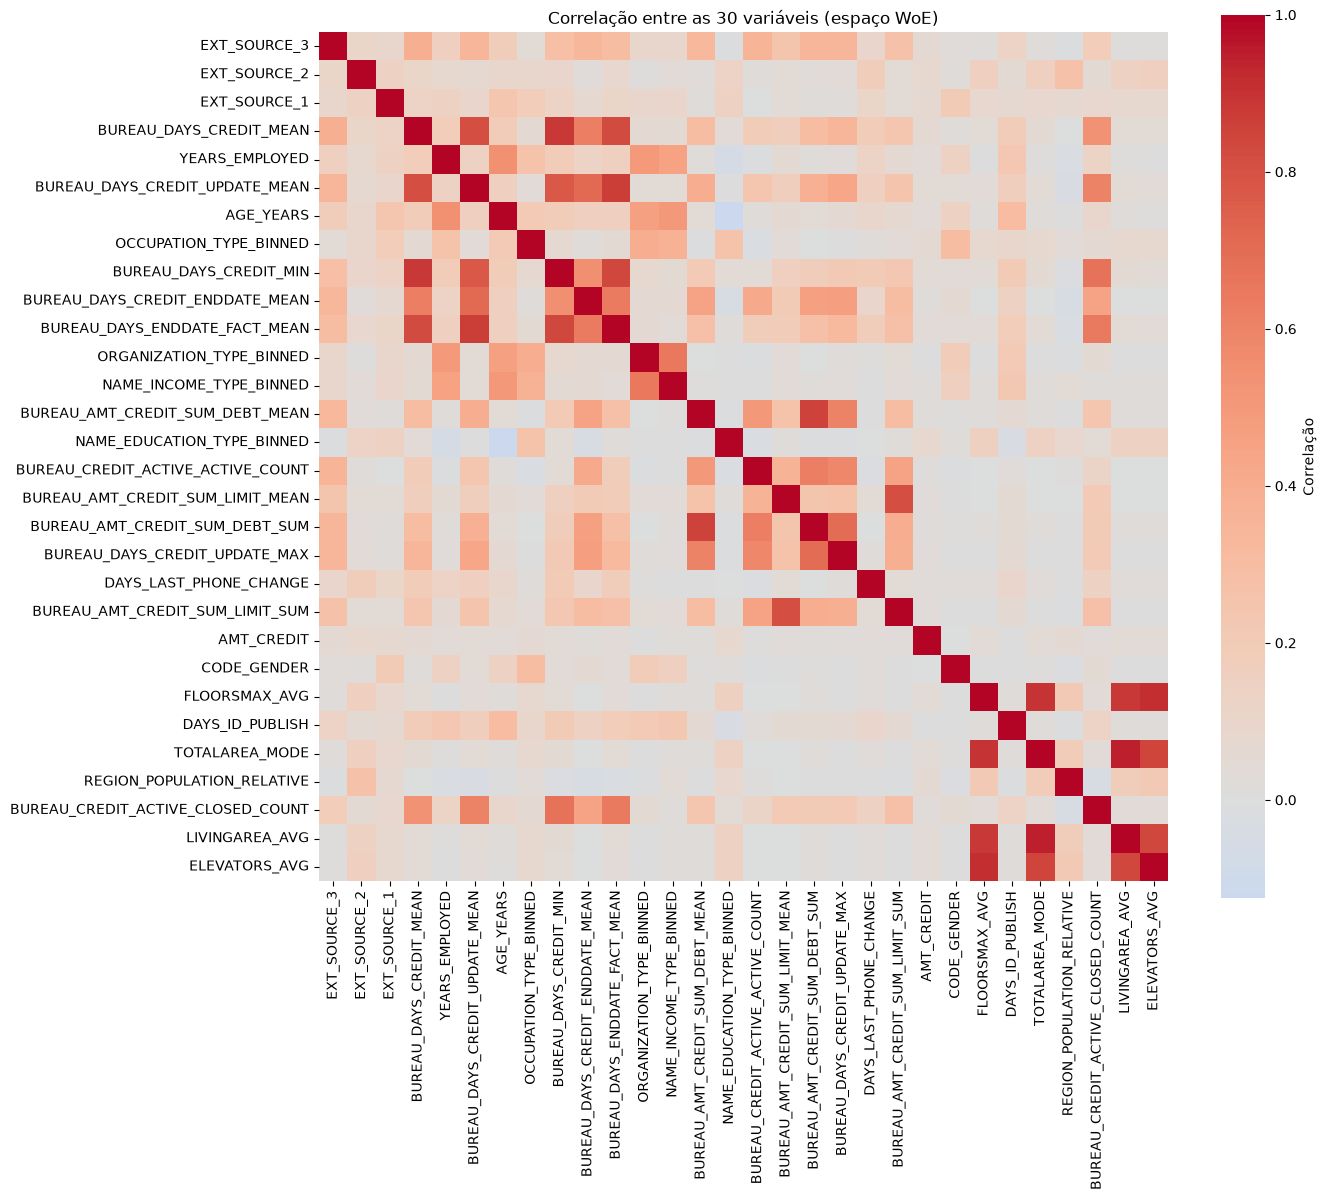

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap of correlation among the 30 WoE-transformed features, to visually
# spot clusters of highly correlated (redundant) variables.

plt.figure(figsize=(14, 12))
sns.heatmap(X_train_woe.corr(), cmap='coolwarm', center=0, annot=False,
            square=True, cbar_kws={'label': 'Correlação'})
plt.title('Correlação entre as 30 variáveis (espaço WoE)')
plt.tight_layout()
plt.show()

In [56]:
# Systematically list all variable pairs with correlation above a threshold,
# across all 30 WoE features, not just the ones already suspected.

corr_matrix = X_train_woe.corr()

# Take only the upper triangle (excluding the diagonal), to avoid listing
# each pair twice (A-B and B-A) or matching a variable against itself.
pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack()
pairs = pairs.reset_index()
pairs.columns = ['var_1', 'var_2', 'correlation']

threshold = 0.7
high_corr_pairs = pairs[pairs['correlation'].abs() >= threshold].sort_values('correlation', ascending=False)

print(f"Pares com |correlação| >= {threshold}:")
print(high_corr_pairs.to_string(index=False))

Pares com |correlação| >= 0.7:
                           var_1                           var_2  correlation
                  TOTALAREA_MODE                  LIVINGAREA_AVG     0.944492
                   FLOORSMAX_AVG                   ELEVATORS_AVG     0.920159
                   FLOORSMAX_AVG                  TOTALAREA_MODE     0.898307
                   FLOORSMAX_AVG                  LIVINGAREA_AVG     0.890061
         BUREAU_DAYS_CREDIT_MEAN          BUREAU_DAYS_CREDIT_MIN     0.889819
  BUREAU_DAYS_CREDIT_UPDATE_MEAN   BUREAU_DAYS_ENDDATE_FACT_MEAN     0.865103
 BUREAU_AMT_CREDIT_SUM_DEBT_MEAN  BUREAU_AMT_CREDIT_SUM_DEBT_SUM     0.853267
                  TOTALAREA_MODE                   ELEVATORS_AVG     0.847204
          BUREAU_DAYS_CREDIT_MIN   BUREAU_DAYS_ENDDATE_FACT_MEAN     0.841661
                  LIVINGAREA_AVG                   ELEVATORS_AVG     0.841357
         BUREAU_DAYS_CREDIT_MEAN   BUREAU_DAYS_ENDDATE_FACT_MEAN     0.824328
         BUREAU_DAYS_CREDIT_MEAN 

In [57]:
# Systematic pruning: for each highly correlated pair, drop the variable
# with lower individual IV, keeping the stronger one. Process pairs from
# highest to lowest correlation, so the most redundant relationships are
# resolved first.

iv_lookup = dict(zip(final_table['variable'], final_table['iv']))
# ELEVATORS_AVG's IV from its own calculation, not in final_table originally.
iv_lookup['ELEVATORS_AVG'] = 0.0329

to_remove = set()
for _, row in high_corr_pairs.sort_values('correlation', ascending=False).iterrows():
    v1, v2 = row['var_1'], row['var_2']
    if v1 in to_remove or v2 in to_remove:
        continue
    weaker = v1 if iv_lookup.get(v1, 0) < iv_lookup.get(v2, 0) else v2
    to_remove.add(weaker)

print("Variáveis a remover por redundância:", len(to_remove))
print(sorted(to_remove))
print()
print("Variáveis remanescentes:", 30 - len(to_remove))

Variáveis a remover por redundância: 8
['BUREAU_AMT_CREDIT_SUM_DEBT_SUM', 'BUREAU_AMT_CREDIT_SUM_LIMIT_SUM', 'BUREAU_DAYS_CREDIT_MIN', 'BUREAU_DAYS_CREDIT_UPDATE_MEAN', 'BUREAU_DAYS_ENDDATE_FACT_MEAN', 'ELEVATORS_AVG', 'LIVINGAREA_AVG', 'TOTALAREA_MODE']

Variáveis remanescentes: 22


In [58]:
# Rebuild the final variable list, dropping redundant (highly correlated,
# lower-IV) variables, then re-fit and re-measure AUC.

final_vars_pruned = [v for v in final_top_30_variables if v not in to_remove]
print("Variáveis finais:", len(final_vars_pruned))
print(final_vars_pruned)

X_train_woe_pruned = X_train_woe[final_vars_pruned]
X_val_woe_pruned = X_val_woe[final_vars_pruned]

model_scorecard_v2 = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model_scorecard_v2.fit(X_train_woe_pruned, y_train)

y_pred_proba_v2 = model_scorecard_v2.predict_proba(X_val_woe_pruned)[:, 1]
auc_v2 = roc_auc_score(y_val, y_pred_proba_v2)

print()
print("AUC (30 variáveis, com redundância):", round(auc_scorecard, 4))
print("AUC (variáveis enxutas, sem redundância):", round(auc_v2, 4))

Variáveis finais: 22
['EXT_SOURCE_3', 'EXT_SOURCE_2', 'EXT_SOURCE_1', 'BUREAU_DAYS_CREDIT_MEAN', 'YEARS_EMPLOYED', 'AGE_YEARS', 'OCCUPATION_TYPE_BINNED', 'BUREAU_DAYS_CREDIT_ENDDATE_MEAN', 'ORGANIZATION_TYPE_BINNED', 'NAME_INCOME_TYPE_BINNED', 'BUREAU_AMT_CREDIT_SUM_DEBT_MEAN', 'NAME_EDUCATION_TYPE_BINNED', 'BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT', 'BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN', 'BUREAU_DAYS_CREDIT_UPDATE_MAX', 'DAYS_LAST_PHONE_CHANGE', 'AMT_CREDIT', 'CODE_GENDER', 'FLOORSMAX_AVG', 'DAYS_ID_PUBLISH', 'REGION_POPULATION_RELATIVE', 'BUREAU_CREDIT_ACTIVE_CLOSED_COUNT']

AUC (30 variáveis, com redundância): 0.7417
AUC (variáveis enxutas, sem redundância): 0.7408


In [59]:
# Re-check coefficient signs on the pruned model: multicollinearity was the
# main suspected cause of inverted signs, so this should show fewer (or no)
# unexpected positive coefficients now.

coef_check_v2 = pd.DataFrame({
    'variable': X_train_woe_pruned.columns,
    'coefficient': model_scorecard_v2.coef_[0]
}).sort_values('coefficient')

print(coef_check_v2.to_string(index=False))
print()
print("Coeficientes positivos (inesperados):", (coef_check_v2['coefficient'] > 0).sum())
print("Comparação, antes da poda:", 8)

                         variable  coefficient
                     EXT_SOURCE_2    -0.765605
                     EXT_SOURCE_3    -0.760621
       NAME_EDUCATION_TYPE_BINNED    -0.574434
                     EXT_SOURCE_1    -0.540386
                       AMT_CREDIT    -0.521517
                      CODE_GENDER    -0.485911
         ORGANIZATION_TYPE_BINNED    -0.403387
                   YEARS_EMPLOYED    -0.392669
                    FLOORSMAX_AVG    -0.320682
BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT    -0.314180
 BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN    -0.247971
           OCCUPATION_TYPE_BINNED    -0.238381
                  DAYS_ID_PUBLISH    -0.233000
  BUREAU_AMT_CREDIT_SUM_DEBT_MEAN    -0.221875
       REGION_POPULATION_RELATIVE    -0.206863
           DAYS_LAST_PHONE_CHANGE    -0.154948
          BUREAU_DAYS_CREDIT_MEAN    -0.103164
  BUREAU_DAYS_CREDIT_ENDDATE_MEAN    -0.015224
BUREAU_CREDIT_ACTIVE_CLOSED_COUNT     0.028284
          NAME_INCOME_TYPE_BINNED     0.049523
             

In [60]:
# Check correlation of the two remaining meaningful-magnitude positive
# coefficients (AGE_YEARS and BUREAU_DAYS_CREDIT_UPDATE_MAX) against the
# full pruned set, to see if any correlation was missed by the earlier
# 0.7 threshold.

print("=== AGE_YEARS ===")
print(X_train_woe_pruned.corr()['AGE_YEARS'].sort_values(ascending=False).head(6))
print()
print("=== BUREAU_DAYS_CREDIT_UPDATE_MAX ===")
print(X_train_woe_pruned.corr()['BUREAU_DAYS_CREDIT_UPDATE_MAX'].sort_values(ascending=False).head(6))

=== AGE_YEARS ===


AGE_YEARS                   1.000000
YEARS_EMPLOYED              0.538407
NAME_INCOME_TYPE_BINNED     0.501942
ORGANIZATION_TYPE_BINNED    0.466210
DAYS_ID_PUBLISH             0.309625
EXT_SOURCE_1                0.236561
Name: AGE_YEARS, dtype: float64

=== BUREAU_DAYS_CREDIT_UPDATE_MAX ===
BUREAU_DAYS_CREDIT_UPDATE_MAX        1.000000
BUREAU_AMT_CREDIT_SUM_DEBT_MEAN      0.602642
BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT    0.585025
BUREAU_DAYS_CREDIT_ENDDATE_MEAN      0.475958
EXT_SOURCE_3                         0.350358
BUREAU_DAYS_CREDIT_MEAN              0.346299
Name: BUREAU_DAYS_CREDIT_UPDATE_MAX, dtype: float64


In [61]:
# Verify individual WoE pattern for the 4 flagged variables, using the
# frozen structures already built (not recalculating anything).

for var in ['AGE_YEARS', 'BUREAU_CREDIT_ACTIVE_CLOSED_COUNT', 'BUREAU_DAYS_CREDIT_UPDATE_MAX']:
    spec = frozen[var]
    print(f"=== {var} ===")
    for edge_lo, edge_hi, woe in zip(spec['edges'][:-1], spec['edges'][1:], spec['bin_woe_ordered']):
        print(f"({edge_lo}, {edge_hi}]  woe={woe:.4f}")
    print(f"Missing woe: {spec['missing_woe']}")
    print()

print("=== NAME_INCOME_TYPE_BINNED ===")
print(frozen['NAME_INCOME_TYPE_BINNED']['table'][['bin', 'woe']].round(4).to_string(index=False))

=== AGE_YEARS ===
(-inf, 28.2]  woe=-0.4087
(28.2, 32.0]  woe=-0.3383
(32.0, 36.0]  woe=-0.2117
(36.0, 39.5]  woe=-0.1025
(39.5, 43.1]  woe=0.0062
(43.1, 47.2]  woe=0.0565
(47.2, 51.7]  woe=0.1396
(51.7, 56.1]  woe=0.2661
(56.1, 60.8]  woe=0.4326
(60.8, inf]  woe=0.5456
Missing woe: None

=== BUREAU_CREDIT_ACTIVE_CLOSED_COUNT ===
(-inf, 1.0]  woe=-0.1634
(1.0, 2.0]  woe=0.0958
(2.0, 3.0]  woe=0.1871
(3.0, 4.0]  woe=0.2174
(4.0, 6.0]  woe=0.1660
(6.0, 8.0]  woe=0.2080
(8.0, inf]  woe=0.1847
Missing woe: -0.24855671204462745

=== BUREAU_DAYS_CREDIT_UPDATE_MAX ===
(-inf, -482.0]  woe=0.3720
(-482.0, -98.0]  woe=0.4210
(-98.0, -36.0]  woe=0.2827
(-36.0, -25.0]  woe=0.0562
(-25.0, -19.0]  woe=0.0410
(-19.0, -14.0]  woe=-0.0017
(-14.0, -11.0]  woe=-0.0847
(-11.0, -8.0]  woe=-0.1149
(-8.0, -5.0]  woe=-0.1277
(-5.0, inf]  woe=-0.2417
Missing woe: -0.2484878340890932

=== NAME_INCOME_TYPE_BINNED ===
                 bin     woe
             Working -0.1829
Commercial associate  0.0667
       St

In [62]:
import statsmodels.api as sm

# Groups defined by information type, EXT_SOURCE placed last per Vitor's
# ordering. Each group is assessed independently, and every variable with
# a statistically significant p-value (< 0.05) is kept, no fixed count.

GROUPS = {
    'demografia_negocio': ['AGE_YEARS', 'YEARS_EMPLOYED', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE',
                            'CODE_GENDER', 'NAME_EDUCATION_TYPE_BINNED', 'NAME_INCOME_TYPE_BINNED',
                            'OCCUPATION_TYPE_BINNED', 'ORGANIZATION_TYPE_BINNED', 'REGION_POPULATION_RELATIVE'],
    'credito_atual': ['AMT_CREDIT', 'FLOORSMAX_AVG'],
    'bureau_historico': ['BUREAU_DAYS_CREDIT_MEAN', 'BUREAU_DAYS_CREDIT_ENDDATE_MEAN',
                          'BUREAU_DAYS_CREDIT_UPDATE_MAX', 'BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT',
                          'BUREAU_CREDIT_ACTIVE_CLOSED_COUNT', 'BUREAU_AMT_CREDIT_SUM_DEBT_MEAN',
                          'BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN'],
    'score_externo': ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'],
}

SIGNIFICANCE_THRESHOLD = 0.05
selected_vars = []

for group_name, group_vars in GROUPS.items():
    X_group = sm.add_constant(X_train_woe_pruned[group_vars])
    model_group = sm.Logit(y_train, X_group).fit(disp=0)

    pvalues = model_group.pvalues.drop('const').sort_values()
    significant = pvalues[pvalues < SIGNIFICANCE_THRESHOLD].index.tolist()

    print(f"=== {group_name} ===")
    print(pvalues.round(4))
    print(f"Significativas (p < {SIGNIFICANCE_THRESHOLD}): {significant}")
    print()

    selected_vars.extend(significant)

print("Variáveis finais, todos os grupos:", len(selected_vars))
print(selected_vars)

=== demografia_negocio ===
NAME_EDUCATION_TYPE_BINNED    0.0000
REGION_POPULATION_RELATIVE    0.0000
DAYS_LAST_PHONE_CHANGE        0.0000
YEARS_EMPLOYED                0.0000
AGE_YEARS                     0.0000
CODE_GENDER                   0.0000
OCCUPATION_TYPE_BINNED        0.0000
DAYS_ID_PUBLISH               0.0000
ORGANIZATION_TYPE_BINNED      0.0000
NAME_INCOME_TYPE_BINNED       0.0185
dtype: float64
Significativas (p < 0.05): ['NAME_EDUCATION_TYPE_BINNED', 'REGION_POPULATION_RELATIVE', 'DAYS_LAST_PHONE_CHANGE', 'YEARS_EMPLOYED', 'AGE_YEARS', 'CODE_GENDER', 'OCCUPATION_TYPE_BINNED', 'DAYS_ID_PUBLISH', 'ORGANIZATION_TYPE_BINNED', 'NAME_INCOME_TYPE_BINNED']

=== credito_atual ===
AMT_CREDIT       0.0
FLOORSMAX_AVG    0.0
dtype: float64
Significativas (p < 0.05): ['AMT_CREDIT', 'FLOORSMAX_AVG']

=== bureau_historico ===
BUREAU_DAYS_CREDIT_MEAN              0.0000
BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN     0.0000
BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT    0.0000
BUREAU_AMT_CREDIT_SUM_DEBT_MEAN

In [63]:
# Cumulative stepwise-by-group: fit the model adding one group at a time,
# in the order Vitor defined (EXT_SOURCE last), tracking how coefficients
# behave as each new group is introduced. This is the part of Siddiqi's
# method that actually addresses dominance, not just per-group significance.

group_order = ['demografia_negocio', 'credito_atual', 'bureau_historico', 'score_externo']
flagged_vars = ['AGE_YEARS', 'BUREAU_CREDIT_ACTIVE_CLOSED_COUNT', 'NAME_INCOME_TYPE_BINNED',
                'BUREAU_DAYS_CREDIT_UPDATE_MAX']

cumulative_vars = []
for step_num, group_name in enumerate(group_order, start=1):
    cumulative_vars.extend(GROUPS[group_name])

    X_step = sm.add_constant(X_train_woe_pruned[cumulative_vars])
    model_step = sm.Logit(y_train, X_step).fit(disp=0)

    print(f"=== Após adicionar '{group_name}' (step {step_num}, {len(cumulative_vars)} variáveis) ===")
    for var in flagged_vars:
        if var in cumulative_vars:
            coef = model_step.params[var]
            pval = model_step.pvalues[var]
            sign_flag = "⚠ POSITIVO (inesperado)" if coef > 0 else "OK (negativo)"
            print(f"  {var}: coef={coef:.4f}, p={pval:.4f}  {sign_flag}")
    print()

=== Após adicionar 'demografia_negocio' (step 1, 10 variáveis) ===
  AGE_YEARS: coef=-0.4663, p=0.0000  OK (negativo)
  NAME_INCOME_TYPE_BINNED: coef=0.1047, p=0.0185  ⚠ POSITIVO (inesperado)

=== Após adicionar 'credito_atual' (step 2, 12 variáveis) ===
  AGE_YEARS: coef=-0.4323, p=0.0000  OK (negativo)
  NAME_INCOME_TYPE_BINNED: coef=0.1054, p=0.0179  ⚠ POSITIVO (inesperado)

=== Após adicionar 'bureau_historico' (step 3, 19 variáveis) ===
  AGE_YEARS: coef=-0.3068, p=0.0000  OK (negativo)
  BUREAU_CREDIT_ACTIVE_CLOSED_COUNT: coef=0.4029, p=0.0000  ⚠ POSITIVO (inesperado)
  NAME_INCOME_TYPE_BINNED: coef=0.0772, p=0.0853  ⚠ POSITIVO (inesperado)
  BUREAU_DAYS_CREDIT_UPDATE_MAX: coef=0.1285, p=0.0101  ⚠ POSITIVO (inesperado)

=== Após adicionar 'score_externo' (step 4, 22 variáveis) ===
  AGE_YEARS: coef=0.1241, p=0.0003  ⚠ POSITIVO (inesperado)
  BUREAU_CREDIT_ACTIVE_CLOSED_COUNT: coef=0.0247, p=0.6261  ⚠ POSITIVO (inesperado)
  NAME_INCOME_TYPE_BINNED: coef=-0.0111, p=0.8093  OK (neg

In [64]:
# Test model without EXT_SOURCE entirely: measure AUC drop and check
# whether coefficient signs become fully consistent without the dominant
# score group competing with the rest.

vars_no_ext_source = [v for v in final_vars_pruned if not v.startswith('EXT_SOURCE')]
print("Variáveis sem EXT_SOURCE:", len(vars_no_ext_source))

X_train_no_ext = X_train_woe_pruned[vars_no_ext_source]
X_val_no_ext = X_val_woe_pruned[vars_no_ext_source]

model_no_ext = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model_no_ext.fit(X_train_no_ext, y_train)

y_pred_no_ext = model_no_ext.predict_proba(X_val_no_ext)[:, 1]
auc_no_ext = roc_auc_score(y_val, y_pred_no_ext)

print()
print("AUC com EXT_SOURCE (22 variáveis):", round(auc_v2, 4))
print("AUC sem EXT_SOURCE (19 variáveis):", round(auc_no_ext, 4))
print("Queda:", round(auc_v2 - auc_no_ext, 4))
print()

coef_no_ext = pd.DataFrame({
    'variable': X_train_no_ext.columns,
    'coefficient': model_no_ext.coef_[0]
}).sort_values('coefficient')

print(coef_no_ext.to_string(index=False))
print()
print("Coeficientes positivos (inesperados):", (coef_no_ext['coefficient'] > 0).sum())

Variáveis sem EXT_SOURCE: 19

AUC com EXT_SOURCE (22 variáveis): 0.7408
AUC sem EXT_SOURCE (19 variáveis): 0.6845
Queda: 0.0563

                         variable  coefficient
       NAME_EDUCATION_TYPE_BINNED    -0.792303
       REGION_POPULATION_RELATIVE    -0.719099
                       AMT_CREDIT    -0.710779
BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT    -0.677249
                      CODE_GENDER    -0.638539
          BUREAU_DAYS_CREDIT_MEAN    -0.612161
           DAYS_LAST_PHONE_CHANGE    -0.565365
                    FLOORSMAX_AVG    -0.506016
                   YEARS_EMPLOYED    -0.481317
 BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN    -0.478464
  BUREAU_AMT_CREDIT_SUM_DEBT_MEAN    -0.392622
           OCCUPATION_TYPE_BINNED    -0.325858
                        AGE_YEARS    -0.320195
         ORGANIZATION_TYPE_BINNED    -0.316878
                  DAYS_ID_PUBLISH    -0.308805
    BUREAU_DAYS_CREDIT_UPDATE_MAX     0.067281
  BUREAU_DAYS_CREDIT_ENDDATE_MEAN     0.070337
          NAME_INCOME_TYP

In [65]:
# Test the bureau_historico group in isolation, to confirm whether the sign
# inconsistencies come from within-group collinearity, independent of
# EXT_SOURCE or any other group.

X_bureau_only = sm.add_constant(X_train_woe_pruned[GROUPS['bureau_historico']])
model_bureau_only = sm.Logit(y_train, X_bureau_only).fit(disp=0)

print(model_bureau_only.summary())

                           Logit Regression Results                           
Dep. Variable:                 TARGET   No. Observations:               246008
Model:                          Logit   Df Residuals:                   246000
Method:                           MLE   Df Model:                            7
Date:                Sun, 16 Aug 2026   Pseudo R-squ.:                 0.02259
Time:                        15:51:33   Log-Likelihood:                -67458.
converged:                       True   LL-Null:                       -69017.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                -2.4344      0.008   -321.612      0.000      -2.449      -2.420
BUREAU_DAYS_CREDIT_MEAN              -0.9827      0.031    -31

In [66]:
# Correlation matrix within the bureau_historico group only, lower threshold
# since this collinearity is more subtle than the >0.7 pairs already pruned.

print(X_train_woe_pruned[GROUPS['bureau_historico']].corr().round(2))

                                   BUREAU_DAYS_CREDIT_MEAN  BUREAU_DAYS_CREDIT_ENDDATE_MEAN  BUREAU_DAYS_CREDIT_UPDATE_MAX  \
BUREAU_DAYS_CREDIT_MEAN                               1.00                             0.63                           0.35   
BUREAU_DAYS_CREDIT_ENDDATE_MEAN                       0.63                             1.00                           0.48   
BUREAU_DAYS_CREDIT_UPDATE_MAX                         0.35                             0.48                           1.00   
BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT                     0.19                             0.42                           0.59   
BUREAU_CREDIT_ACTIVE_CLOSED_COUNT                     0.53                             0.45                           0.20   
BUREAU_AMT_CREDIT_SUM_DEBT_MEAN                       0.30                             0.45                           0.60   
BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN                      0.17                             0.20                           

In [67]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF measures how much a variable's variance is inflated by its correlation
# with ALL other variables combined, catching diffuse multicollinearity that
# pairwise correlation (checked above) can miss.

X_bureau_vif = X_train_woe_pruned[GROUPS['bureau_historico']]
vif_data = pd.DataFrame({
    'variable': X_bureau_vif.columns,
    'VIF': [variance_inflation_factor(X_bureau_vif.values, i) for i in range(X_bureau_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_data.to_string(index=False))

                         variable      VIF
  BUREAU_DAYS_CREDIT_ENDDATE_MEAN 2.143488
    BUREAU_DAYS_CREDIT_UPDATE_MAX 2.018456
          BUREAU_DAYS_CREDIT_MEAN 1.958227
BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT 1.820961
  BUREAU_AMT_CREDIT_SUM_DEBT_MEAN 1.761759
BUREAU_CREDIT_ACTIVE_CLOSED_COUNT 1.502382
 BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN 1.201659


In [68]:
# Retrain with 21 variables, dropping BUREAU_CREDIT_ACTIVE_CLOSED_COUNT
# (not statistically significant, p=0.63 in the 22-variable model, and one
# of the two unresolved sign-inversion cases from the bureau group).

final_vars_21 = [v for v in final_vars_pruned if v != 'BUREAU_CREDIT_ACTIVE_CLOSED_COUNT']
print("Variáveis finais:", len(final_vars_21))

X_train_woe_21 = X_train_woe_pruned[final_vars_21]
X_val_woe_21 = X_val_woe_pruned[final_vars_21]

model_scorecard_v3 = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model_scorecard_v3.fit(X_train_woe_21, y_train)

y_pred_proba_v3 = model_scorecard_v3.predict_proba(X_val_woe_21)[:, 1]
auc_v3 = roc_auc_score(y_val, y_pred_proba_v3)

print()
print("AUC (22 variáveis):", round(auc_v2, 4))
print("AUC (21 variáveis, sem BUREAU_CREDIT_ACTIVE_CLOSED_COUNT):", round(auc_v3, 4))
print()

coef_check_v3 = pd.DataFrame({
    'variable': X_train_woe_21.columns,
    'coefficient': model_scorecard_v3.coef_[0]
}).sort_values('coefficient')

print(coef_check_v3.to_string(index=False))
print()
print("Coeficientes positivos (inesperados):", (coef_check_v3['coefficient'] > 0).sum())

Variáveis finais: 21

AUC (22 variáveis): 0.7408
AUC (21 variáveis, sem BUREAU_CREDIT_ACTIVE_CLOSED_COUNT): 0.7408

                         variable  coefficient
                     EXT_SOURCE_2    -0.765670
                     EXT_SOURCE_3    -0.761167
       NAME_EDUCATION_TYPE_BINNED    -0.573311
                     EXT_SOURCE_1    -0.540897
                       AMT_CREDIT    -0.521973
                      CODE_GENDER    -0.484944
         ORGANIZATION_TYPE_BINNED    -0.402238
                   YEARS_EMPLOYED    -0.392689
                    FLOORSMAX_AVG    -0.320496
BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT    -0.312193
 BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN    -0.247009
           OCCUPATION_TYPE_BINNED    -0.236875
                  DAYS_ID_PUBLISH    -0.232051
  BUREAU_AMT_CREDIT_SUM_DEBT_MEAN    -0.219668
       REGION_POPULATION_RELATIVE    -0.207035
           DAYS_LAST_PHONE_CHANGE    -0.153982
          BUREAU_DAYS_CREDIT_MEAN    -0.096869
  BUREAU_DAYS_CREDIT_ENDDATE_MEAN    -

In [69]:
# Test removing the 3 remaining sign-flagged variables entirely, to see if
# this fully resolves sign consistency or shifts the problem elsewhere.

flagged_now = ['AGE_YEARS', 'NAME_INCOME_TYPE_BINNED', 'BUREAU_DAYS_CREDIT_UPDATE_MAX']
vars_no_flagged = [v for v in final_vars_21 if v not in flagged_now]

X_train_no_flagged = X_train_woe_21[vars_no_flagged]
X_val_no_flagged = X_val_woe_21[vars_no_flagged]

model_no_flagged = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model_no_flagged.fit(X_train_no_flagged, y_train)

y_pred_no_flagged = model_no_flagged.predict_proba(X_val_no_flagged)[:, 1]
auc_no_flagged = roc_auc_score(y_val, y_pred_no_flagged)

print("AUC (21 variáveis):", round(auc_v3, 4))
print("AUC (18 variáveis, sem as 3 problemáticas):", round(auc_no_flagged, 4))
print()

coef_no_flagged = pd.DataFrame({
    'variable': X_train_no_flagged.columns,
    'coefficient': model_no_flagged.coef_[0]
}).sort_values('coefficient')

print(coef_no_flagged.to_string(index=False))
print()
print("Coeficientes positivos (inesperados):", (coef_no_flagged['coefficient'] > 0).sum())

AUC (21 variáveis): 0.7408
AUC (18 variáveis, sem as 3 problemáticas): 0.7406

                         variable  coefficient
                     EXT_SOURCE_2    -0.761411
                     EXT_SOURCE_3    -0.755238
       NAME_EDUCATION_TYPE_BINNED    -0.587029
                     EXT_SOURCE_1    -0.525526
                       AMT_CREDIT    -0.519722
                      CODE_GENDER    -0.471338
                   YEARS_EMPLOYED    -0.360594
         ORGANIZATION_TYPE_BINNED    -0.350066
                    FLOORSMAX_AVG    -0.323045
BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT    -0.256060
 BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN    -0.242131
           OCCUPATION_TYPE_BINNED    -0.235479
       REGION_POPULATION_RELATIVE    -0.203097
                  DAYS_ID_PUBLISH    -0.197629
  BUREAU_AMT_CREDIT_SUM_DEBT_MEAN    -0.168019
           DAYS_LAST_PHONE_CHANGE    -0.161854
          BUREAU_DAYS_CREDIT_MEAN    -0.084686
  BUREAU_DAYS_CREDIT_ENDDATE_MEAN     0.011255

Coeficientes positivos (ine

In [70]:
# One more iteration: remove BUREAU_DAYS_CREDIT_ENDDATE_MEAN (coefficient
# ~0.01, essentially neutral) and check if AUC holds and signs stay clean.

vars_17 = [v for v in vars_no_flagged if v != 'BUREAU_DAYS_CREDIT_ENDDATE_MEAN']

X_train_woe_17 = X_train_woe_21[vars_17]
X_val_woe_17 = X_val_woe_21[vars_17]

model_17 = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model_17.fit(X_train_woe_17, y_train)

y_pred_17 = model_17.predict_proba(X_val_woe_17)[:, 1]
auc_17 = roc_auc_score(y_val, y_pred_17)

print("AUC (18 variáveis):", round(auc_no_flagged, 4))
print("AUC (17 variáveis, sem BUREAU_DAYS_CREDIT_ENDDATE_MEAN):", round(auc_17, 4))
print()

coef_17 = pd.DataFrame({
    'variable': X_train_woe_17.columns,
    'coefficient': model_17.coef_[0]
}).sort_values('coefficient')

print(coef_17.to_string(index=False))
print()
print("Coeficientes positivos (inesperados):", (coef_17['coefficient'] > 0).sum())

AUC (18 variáveis): 0.7406
AUC (17 variáveis, sem BUREAU_DAYS_CREDIT_ENDDATE_MEAN): 0.7406

                         variable  coefficient
                     EXT_SOURCE_2    -0.762753
                     EXT_SOURCE_3    -0.755276
       NAME_EDUCATION_TYPE_BINNED    -0.586299
                     EXT_SOURCE_1    -0.526376
                       AMT_CREDIT    -0.518812
                      CODE_GENDER    -0.468886
                   YEARS_EMPLOYED    -0.359414
         ORGANIZATION_TYPE_BINNED    -0.349520
                    FLOORSMAX_AVG    -0.323471
BUREAU_CREDIT_ACTIVE_ACTIVE_COUNT    -0.254907
 BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN    -0.241090
           OCCUPATION_TYPE_BINNED    -0.238311
       REGION_POPULATION_RELATIVE    -0.202920
                  DAYS_ID_PUBLISH    -0.195690
  BUREAU_AMT_CREDIT_SUM_DEBT_MEAN    -0.165283
           DAYS_LAST_PHONE_CHANGE    -0.160958
          BUREAU_DAYS_CREDIT_MEAN    -0.079298

Coeficientes positivos (inesperados): 0
